# Enhancing Signal Stability in Untargeted GC-IMS Metabolomics: Removing Batch and Time Effects via Orthogonal Projections

## Contents
1. [Part 0 - Setup and Data Loading](#part-0---setup-and-data-loading)
2. [Part 1 - Inductive Wrapper Classes](#part-1---inductive-wrapper-classes)
3. [Part 2 - Helper Functions and Model Registry](#part-2---helper-functions-and-model-registry)
4. [Part 3 - Data Generation and Exploration](#part-3---data-generation-and-exploration)
5. [Part 4 - Comparing Methods Across Parameter Space](#part-4---comparing-methods-across-parameter-space)

### Part 3 Subsections
- [3.1 Noise Correction Inductive Validation](#31---noise-correction-inductive-validation)
- [3.1.1 Correction Method Tuning](#311---correction-method-tuning)
- [3.1.2 Noise Correction Validation](#312---noise-correction-validation)
- [3.3 Classification Task Evaluation](#33---classification-task-evaluation)
- [3.3.1 OPAT (One Parameter at a Time) Analysis](#331---opat-one-parameter-at-a-time-analysis)
- [3.3.2  Classification task pre vs post correction with default parameters](#332---classification-task-pre-vs-post-correction-with-default-parameters)
- 3.3.3 Scalability analysis

### Part 4 Subsections
- [4.0 Pre-Grid-Search Classifier and Method Parameter Optimization](#40---pre-grid-search-classifier-and-method-parameter-optimization)
- [4.1 Grid Search Evaluation](#41---grid-search-evaluation)
- [4.1.1 Grid Search Execution](#411---grid-search-execution)


## Notebook Overview

This notebook evaluates Duran et al's method for correcting batch and acquisition-order effects in untargeted GC-IMS metabolomics data. In this project this method has two variants with different methodologies for performing induction on new samples: `ISFO` and `INSOC`). The workflow compares the method under controlled synthetic signal scenarios and quantifies downstream classification performance compared with standard correction methods such as LOESS and SERRF.

## Part 0 - Setup and Data Loading

In this section, we import all required libraries and configure paths to include the `src` folder. This provides access to the custom data-loading utilities, synthetic data engine (`SimpleClinicalSyntheticGCIMSEngine`), and drift-correction models (`ISFO`, `LOESSCorrector`, `SERRFCorrector`).

In [ ]:
# =============================================================================
# IMPORTS
# =============================================================================

# --- Standard library ---------------------------------------------------------
import inspect                  # Inspect function signatures dynamically.
import itertools                # Build iterators for combinatorial workflows.
import os                       # Interact with the operating system and paths.
import re                       # Regular expressions for text pattern handling.
import sys                      # Manage Python path and interpreter-level settings.
import warnings                 # Control and filter warning messages.
from contextlib import contextmanager  # Build context managers for scoped behavior.
from copy import deepcopy       # Copy complex objects without shared references.
from pathlib import Path        # Cross-platform filesystem path handling.


# --- Parallelism and utilities ------------------------------------------------
import joblib                         # Serialization and parallel backend utilities.
from joblib import Parallel, delayed  # Parallel execution primitives.
from tqdm import tqdm                 # Progress bars for loops and batch jobs.


# --- Numerical and tabular data ----------------------------------------------
import numpy as np              # Numerical arrays and vectorized operations.
import pandas as pd             # Tabular data structures and transformations.


# --- Statistical analysis -----------------------------------------------------
import scipy.stats as stats     # General statistical routines.
from scipy.interpolate import interp1d  # Dynamic interpolation for QC -> patient projection.
from scipy.stats import kruskal, linregress, norm  # Specific hypothesis tests and trend tools.
from statsmodels.stats.multitest import fdrcorrection  # FDR correction for multiple testing.


# --- Visualization ------------------------------------------------------------
import matplotlib.pyplot as plt             # Core plotting API for static figures.
import matplotlib.figure as mpl_figure      # Figure class for save tracking hooks.
import matplotlib.backend_bases as mpl_backend_bases  # Canvas-level save tracking.
import matplotlib.gridspec as gridspec      # Advanced subplot grid layouts.
import matplotlib.ticker as mticker         # Tick format control.
from matplotlib.ticker import FuncFormatter # Custom axis tick label formatting.
import seaborn as sns                       # High-level statistical visualization layer.
import plotly.express as px                 # High-level interactive plotting.
import plotly.graph_objects as go           # Low-level interactive figure control.
import plotly.io as pio                     # Plotly template and renderer configuration.
from plotly.subplots import make_subplots   # Multi-panel Plotly figure layouts.
from PIL import Image                       # Image export for Plotly figures.


# --- Machine learning (scikit-learn) -----------------------------------------
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin  # Custom estimator APIs.
from sklearn.cross_decomposition import PLSRegression  # PLS backbone for PLS-DA classifier.
from sklearn.decomposition import PCA                     # Principal component analysis.
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score  # Evaluation metrics.
from sklearn.model_selection import LeaveOneGroupOut, train_test_split, cross_validate  # Splits and CV strategies.
from sklearn.pipeline import Pipeline                     # Chain preprocessors and estimators.
from sklearn.preprocessing import StandardScaler          # Feature standardization.
from sklearn.utils.validation import check_is_fitted     # Validate fitted estimator state.


# --- Hyperparameter optimization ---------------------------------------------
import optuna                    # Bayesian/efficient hyperparameter optimization.


# =============================================================================
# GLOBAL PLOTTING / WARNING CONFIGURATION
# =============================================================================
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)

# Consistent style across matplotlib/seaborn/plotly
PLOT_FONT_FAMILY = "Arial"
PLOT_FONT_TITLE = 14
PLOT_FONT_LABEL = 12
PLOT_FONT_TICK = 10
PLOT_LINE_WIDTH = 2.0
PLOT_EDGE_WIDTH = 0.8

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(
    style="whitegrid",
    rc={
        "font.family": PLOT_FONT_FAMILY,
        "axes.titlesize": PLOT_FONT_TITLE,
        "axes.labelsize": PLOT_FONT_LABEL,
        "xtick.labelsize": PLOT_FONT_TICK,
        "ytick.labelsize": PLOT_FONT_TICK,
        "lines.linewidth": PLOT_LINE_WIDTH,
        "patch.linewidth": PLOT_EDGE_WIDTH,
    },
)
plt.rcParams.update({
    "font.family": PLOT_FONT_FAMILY,
    "axes.titlesize": PLOT_FONT_TITLE,
    "axes.labelsize": PLOT_FONT_LABEL,
    "xtick.labelsize": PLOT_FONT_TICK,
    "ytick.labelsize": PLOT_FONT_TICK,
    "lines.linewidth": PLOT_LINE_WIDTH,
    "axes.linewidth": PLOT_EDGE_WIDTH,
    "grid.linewidth": 0.8,
})

pio.templates["gcims_white"] = go.layout.Template(pio.templates["plotly_white"])
pio.templates["gcims_white"].layout.update(
    font=dict(family=PLOT_FONT_FAMILY, size=PLOT_FONT_LABEL),
    title=dict(font=dict(size=PLOT_FONT_TITLE)),
    xaxis=dict(title=dict(font=dict(size=PLOT_FONT_LABEL)), tickfont=dict(size=PLOT_FONT_TICK)),
    yaxis=dict(title=dict(font=dict(size=PLOT_FONT_LABEL)), tickfont=dict(size=PLOT_FONT_TICK)),
)
pio.templates.default = "gcims_white"

# =============================================================================
# PROJECT PATHS AND LOCAL IMPORTS
# =============================================================================
# -- Project root on path
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# -- Project modules
from src.utils import load_data                                # Load data matrices and metadata.
from src.synthetic_engine import SimpleClinicalSyntheticGCIMSEngine  # Synthetic GC-IMS scenario generator.
from src.models import (
    ISFO, LOESSCorrector, SERRFCorrector              # Batch/time correction model implementations.
)

# Paths
DATA_X = ROOT / "data" / "peak_table_pool.csv"
DATA_META = ROOT / "data" / "annotations_pool.csv"

print("Root:", ROOT)

# =============================================================================
# FIGURE EXPORT CONFIGURATION
# =============================================================================
# Figure export folder (used by all visualization cells)
FIGURES_DIR = ROOT / "docs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_clean_figure(fig, filename: str, dpi: int = 600):
    """
    Explicitly saves a Matplotlib figure to the figures directory with a meaningful name.
    """
    filepath = FIGURES_DIR / filename
    fig.savefig(filepath, dpi=dpi, bbox_inches="tight")
    print(f"[INFO] Matplotlib figure saved successfully: {filepath}")


def save_clean_plotly(fig, filename_base: str, width: int = 1200, height: int = 800, scale: int = 6, dpi: int = 600):
    """
    Explicitly saves a Plotly figure as a high-resolution static PNG and forces 
    the correct DPI metadata for scientific publication.
    """
    filepath = FIGURES_DIR / f"{filename_base}.png"
    
    # 1. Kaleido renderiza y guarda la imagen de alta resolución (pero con metadato erróneo)
    fig.write_image(str(filepath), width=width, height=height, scale=scale)
    
    # 2. Pillow (PIL) abre el archivo e inyecta el metadato DPI correcto
    try:
        img = Image.open(str(filepath))
        img.save(str(filepath), dpi=(dpi, dpi))
        print(f"[INFO] Plotly figure saved successfully as PNG at {dpi} DPI: {filepath}")
    except Exception as e:
        print(f"[WARNING] Could not update DPI metadata using Pillow. Error: {e}")
    
    

print(f"Figure saving enabled. Target directory: {FIGURES_DIR}")

Root: c:\Users\adria\OneDrive\Escritorio\bueno_ibecp4048
Figure saving enabled. Target directory: c:\Users\adria\OneDrive\Escritorio\bueno_ibecp4048\docs\figures


In [2]:
# Loading data from the peak_table_var.csv in the data folder
X_df, meta_df = load_data("../data/peak_table_var.csv")

required_meta = ["batch", "elapsed_time"]
missing = [c for c in required_meta if c not in meta_df.columns]
if missing:
    raise ValueError(f"Missing required metadata columns: {missing}")

# Combined table to simplify grouping
df = pd.concat([meta_df.reset_index(drop=True), X_df.reset_index(drop=True)], axis=1)
feature_names = X_df.columns.tolist()

# Acquisition order within each batch (0 ... n_per_batch-1)
df["acq_order"] = (
    df.groupby("batch")["elapsed_time"]
    .rank(method="first")
    .astype(int) - 1
)

# Working arrays
X_raw      = X_df.to_numpy(dtype=float)
batch      = df["batch"].to_numpy()
elapsed    = df["elapsed_time"].to_numpy(dtype=float)
acq_order  = df["acq_order"].to_numpy()

# Full meta_df (for audits that use elapsed_time, etc.)
meta_df = df[meta_df.columns.tolist() + ["acq_order"]].copy()

# meta_models: only columns used by correction models
meta_models = meta_df[["batch", "acq_order"]].copy()

# Semantic columns
batch_col = "batch"
time_col  = "acq_order"

batches        = meta_df[batch_col].values
unique_batches = np.unique(batches)

n, p = X_raw.shape
print(f"Samples (n)  : {n}")
print(f"Features (p) : {p}")
print(f"Batches      : {unique_batches}  (n={len(unique_batches)})")
print(f"meta_models columns: {meta_models.columns.tolist()}")

Samples (n)  : 135
Features (p) : 31
Batches      : [1 2 3 4 5 6 7 8 9]  (n=9)
meta_models columns: ['batch', 'acq_order']


## Part 1 - Inductive Wrapper Classes

For `ISFO`, the projector is sized `(n_train, n_train)` since it operates directly in the sample-space. This prevents applying it directly to incoming unseen patient matrices (test sets) in an inductive setting.

**Inductive conversion strategy:**
Given a training QC matrix $X_{\text{qc}}$ and its empirical sample-space technical directions
$U \in \mathbb{R}^{n_{\text{qc}} \times k}$, the associated feature-space technical loadings are defined as:

$$W = X_{\text{qc,centered}}^T \, U \in \mathbb{R}^{p \times k}$$

After orthonormalizing $W \to Q$ (via QR decomposition), new unseen data points are corrected by projecting out this feature subspace:

$$X_{\text{corr}} = \bigl(X_{\text{new}} - \bar{x}\bigr)\,(I_p - Q Q^T) + \bar{x}$$

This formulation guarantees that the feature dimensions capturing technical drift are removed, preserving the remaining subspace. In this  notebook, our goal is to suppress shared technical biases so that small fold-changes (A to B classification) become machine-learning visible.

In [3]:
class _InductiveProjectorMixin:
    """Shared feature-space projector for wrappers."""

    def _extract_feature_loadings(self, X_qc_centered: np.ndarray, U_sample: np.ndarray) -> np.ndarray:
        """Convert sample-space directions U (n_qc x k) -> orthonormal feature loadings Q (p x k)."""
        if U_sample.shape[1] == 0:
            return np.zeros((X_qc_centered.shape[1], 0))
        W = X_qc_centered.T @ U_sample
        Q, _ = np.linalg.qr(W)
        return Q[:, : U_sample.shape[1]]

    def _apply_projector(self, X_new: np.ndarray) -> np.ndarray:
        check_is_fitted(self, ["feature_loadings_", "mean_"])
        X_new = np.asarray(X_new, dtype=float)
        X_c = X_new - self.mean_
        Q = self.feature_loadings_
        if Q.shape[1] > 0:
            X_c = X_c - X_c @ Q @ Q.T
        return X_c + self.mean_


def _get_meta_sort_index(meta_like, n_rows: int) -> np.ndarray:
    """Stable ordering by batch/acq_order when metadata is available."""
    if meta_like is None:
        return np.arange(n_rows)

    if not isinstance(meta_like, pd.DataFrame):
        try:
            meta_like = pd.DataFrame(meta_like)
        except Exception:
            return np.arange(n_rows)

    if "batch" in meta_like.columns and "acq_order" in meta_like.columns:
        batch_arr = pd.factorize(meta_like["batch"])[0]
        acq_arr = meta_like["acq_order"].to_numpy()
        return np.lexsort((acq_arr, batch_arr))

    if "acq_order" in meta_like.columns:
        return np.argsort(meta_like["acq_order"].to_numpy())

    return np.arange(n_rows)


class InductiveISFO(_InductiveProjectorMixin, BaseEstimator, TransformerMixin):
    """Inductive wrapper for ISFO (sample-space -> feature-space projector)."""

    def __init__(self, n_components: int = 2, n_components_batch: int = 1, n_components_acq: int = 1):
        self.n_components = n_components
        self.n_components_batch = n_components_batch
        self.n_components_acq = n_components_acq

    def fit(self, X_qc: np.ndarray, meta_qc: pd.DataFrame):
        self._inner = ISFO(
            n_components=self.n_components,
            n_components_batch=self.n_components_batch,
            n_components_acq=self.n_components_acq,
        )
        self._inner.fit(X_qc, meta_qc)
        self.mean_ = self._inner.mean_
        U = self._inner.component_scores_
        X_c = self._inner.X_centered_
        self.feature_loadings_ = self._extract_feature_loadings(X_c, U)
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        return self._apply_projector(X)

    
class InductiveINSOC(BaseEstimator, TransformerMixin):
    """
    Interpolate QCs batch-wise to match target size, fit the standard ISFO,
    and apply the sample-space projection directly to the target.
    """
    def __init__(self, n_components_batch: int = 3, n_components_acq: int = 1):
        self.n_components_batch = n_components_batch
        self.n_components_acq = n_components_acq

    def fit(self, X_qc: np.ndarray, meta_qc: pd.DataFrame):
        self.X_qc_ = np.asarray(X_qc, dtype=float)
        self.meta_qc_ = meta_qc.copy().reset_index(drop=True)
        self.n_features_in_ = self.X_qc_.shape[1]
        return self

    def transform(self, X: np.ndarray, meta_pat: pd.DataFrame = None, meta: pd.DataFrame = None) -> np.ndarray:
        check_is_fitted(self, ["X_qc_", "meta_qc_", "n_features_in_"])
        X = np.asarray(X, dtype=float)
        meta_use = meta_pat if meta_pat is not None else meta
        
        # 1. Order target data chronologically
        order = _get_meta_sort_index(meta_use, X.shape[0])
        inv_order = np.empty_like(order)
        inv_order[order] = np.arange(len(order))
        
        X_sorted = X[order]
        meta_sorted = meta_use.iloc[order].reset_index(drop=True)
        
        # 2. Batch-wise Interpolation (Supervisor's constraint)
        X_qc_interp_list = []
        unique_batches = meta_sorted["batch"].unique()
        
        for b in unique_batches:
            idx_pat = meta_sorted["batch"] == b
            acq_pat = meta_sorted.loc[idx_pat, "acq_order"].values
            
            idx_qc = self.meta_qc_["batch"] == b
            X_qc_b = self.X_qc_[idx_qc]
            acq_qc = self.meta_qc_.loc[idx_qc, "acq_order"].values
            
            if len(X_qc_b) > 1:
                interpolator = interp1d(
                    acq_qc, X_qc_b, axis=0, kind="linear", 
                    bounds_error=False, fill_value="extrapolate"
                )
                X_interp_b = interpolator(acq_pat)
            elif len(X_qc_b) == 1:
                X_interp_b = np.repeat(X_qc_b, len(acq_pat), axis=0)
            else:
                X_interp_b = np.zeros((len(acq_pat), self.n_features_in_))
                
            X_qc_interp_list.append(X_interp_b)
            
        X_qc_interp = np.vstack(X_qc_interp_list)
        
        # 3. Apply standard ISFO directly (The real magic)
        inner_epo = ISFO(
            n_components_batch=self.n_components_batch,
            n_components_acq=self.n_components_acq
        )
        
        # Fit on interpolated QCs to build the sample-space projector
        inner_epo.fit(X_qc_interp, meta_sorted)
        
        # Transform the patients directly utilizing the built-in sample projection
        X_corr_sorted = inner_epo.transform(X_sorted)
        
        return X_corr_sorted[inv_order]
    
    

## Part 2 - Helper Functions & Model Registry

This section contains scaffolding to automate evaluation:
1. `build_correction_models()` constructs fresh instances for fairness.
2. `PLSDAClassifier` acts as the target downstream classifier.
3. `evaluate_inductive_logo()` performs Leave-One-Group-Out cross-validation.

In [4]:
# Define a color map to ensure consistency across all independent plots
COLOR_MAP = {
    "Raw (No Correction)": "#4a4a4a",
    "ISFO": "#0b854c",
    "INSOC": "#c49a6c",
    "LOESSCorrector": "#1bacea",
    "SERRFCorrector": "#e4900a",
}


def adjust_color_brightness(hex_color: str, factor: float) -> str:
    """Returns a lighter (>1) or darker (<1) hex color variant."""
    hex_color = hex_color.lstrip("#")
    rgb = np.array([int(hex_color[i:i+2], 16) for i in (0, 2, 4)], dtype=float)
    if factor >= 1.0:
        rgb = rgb + (255.0 - rgb) * (factor - 1.0)
    else:
        rgb = rgb * factor
    rgb = np.clip(rgb, 0, 255).astype(int)
    return "#" + "".join(f"{v:02x}" for v in rgb)


def apply_consistent_style(ax, title=None, xlabel=None, ylabel=None):
    if title is not None:
        ax.set_title(title, fontsize=PLOT_FONT_TITLE)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=PLOT_FONT_LABEL)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=PLOT_FONT_LABEL)
    ax.tick_params(axis="both", labelsize=PLOT_FONT_TICK, width=PLOT_EDGE_WIDTH)
    for spine in ax.spines.values():
        spine.set_linewidth(PLOT_EDGE_WIDTH)


def apply_plotly_consistent_style(fig, title=None, x_title=None, y_title=None):
    fig.update_layout(
        template="gcims_white",
        font=dict(family=PLOT_FONT_FAMILY, size=PLOT_FONT_LABEL),
        title=dict(text=title if title is not None else None, font=dict(size=PLOT_FONT_TITLE)),
    )
    fig.update_xaxes(title_text=x_title, title_font=dict(size=PLOT_FONT_LABEL), tickfont=dict(size=PLOT_FONT_TICK))
    fig.update_yaxes(title_text=y_title, title_font=dict(size=PLOT_FONT_LABEL), tickfont=dict(size=PLOT_FONT_TICK))
    return fig


# Model registry
def build_correction_models() -> dict:
    """Return one fresh instance of each correction model."""
    return {
        "ISFO": InductiveISFO(n_components_batch=3, n_components_acq=1),
        "INSOC": InductiveINSOC(n_components_batch=3, n_components_acq=1),
        "LOESSCorrector": LOESSCorrector(frac=0.35, it=4),
        "SERRFCorrector": SERRFCorrector(n_estimators=20, max_depth=2, min_samples_split=3, random_state=42),
    }


def build_core_correction_models() -> dict:
    """Methods used in restricted sections (Raw + EPO variants)."""
    return {
        "ISFO": InductiveISFO(n_components_batch=3, n_components_acq=1),
        "INSOC": InductiveINSOC(n_components_batch=3, n_components_acq=1),
    }


# Baseline classifier: PLS-DA (Partial Least Squares Discriminant Analysis)
class PLSDAClassifier(ClassifierMixin, BaseEstimator):
    
    # Explicitly enforce classifier identity
    _estimator_type = "classifier"
    
    def __init__(self, n_components=2):
        self.n_components = n_components
        
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        
        self.scaler_ = StandardScaler()
        X_scaled = self.scaler_.fit_transform(X)
        
        self.pls_ = PLSRegression(n_components=self.n_components)
        y_encoded = np.where(y == self.classes_[0], -1, 1)
        self.pls_.fit(X_scaled, y_encoded)
        
        return self
        
    def predict_proba(self, X):
        check_is_fitted(self, ['pls_', 'scaler_'])
        
        X_scaled = self.scaler_.transform(X)
        preds = self.pls_.predict(X_scaled).ravel()
        
        p_min, p_max = preds.min(), preds.max()
        if p_max == p_min:
            preds_scaled = np.full_like(preds, 0.5)
        else:
            preds_scaled = (preds - p_min) / (p_max - p_min)
            
        preds_scaled = np.clip(preds_scaled, 0.0, 1.0)
        return np.vstack([1 - preds_scaled, preds_scaled]).T
        
    def predict(self, X):
        check_is_fitted(self, ['pls_', 'scaler_'])
        X_scaled = self.scaler_.transform(X)
        preds = self.pls_.predict(X_scaled).ravel()
        return np.where(preds > 0, self.classes_[1], self.classes_[0])


# Focused on PLS-DA as the primary classifier for evaluation; potentially adding different classifiers for comparison.
def build_classifiers(pls_components=2):
    return {
        "PLS-DA": PLSDAClassifier(n_components=pls_components),
    }


def _fit_transform_foldwise(model, X_qc, meta_qc, qc_batches, Xtr, Xte, meta_tr, meta_te):
    
    if not isinstance(meta_tr, pd.DataFrame):
        meta_tr = pd.DataFrame(meta_tr, columns=['batch', 'acq_order'])
    if not isinstance(meta_te, pd.DataFrame):
        meta_te = pd.DataFrame(meta_te, columns=['batch', 'acq_order'])
        
    meta_tr = meta_tr.reset_index(drop=True)
    meta_te = meta_te.reset_index(drop=True)
    
    m = deepcopy(model).fit(X_qc, meta_qc)
    sig = inspect.signature(m.transform).parameters

    if "meta_pat" in sig:
        Xtr_c = m.transform(Xtr, meta_pat=meta_tr)
        Xte_c = m.transform(Xte, meta_pat=meta_te)
    elif "meta" in sig:
        Xtr_c = m.transform(Xtr, meta=meta_tr)
        Xte_c = m.transform(Xte, meta=meta_te)
    else:
        Xtr_c = m.transform(Xtr)
        Xte_c = m.transform(Xte)

    return Xtr_c, Xte_c

In [5]:
def evaluate_inductive_logo(
    X_pat: np.ndarray,
    y_pat: np.ndarray,
    groups_pat: np.ndarray,
    X_qc: np.ndarray,
    meta_qc: pd.DataFrame,
    qc_batches: np.ndarray,
    correction_models: dict,
    classifiers: dict,
    meta_pat: pd.DataFrame,
) -> pd.DataFrame:
    """Evaluate correction methods under Leave-One-Group-Out CV."""
    logo = LeaveOneGroupOut()
    records = []

    for method_name, model in correction_models.items():
        for clf_name, clf in classifiers.items():
            fold_auc, fold_acc, fold_f1, fold_prec, fold_rec = [], [], [], [], []

            for tr, te in logo.split(X_pat, y_pat, groups=groups_pat):
                y_tr, y_te = y_pat[tr], y_pat[te]
                Xtr, Xte = X_pat[tr], X_pat[te]
                meta_tr = meta_pat.iloc[tr].reset_index(drop=True)
                meta_te = meta_pat.iloc[te].reset_index(drop=True)

                if model is None:
                    Xtr_c, Xte_c = Xtr, Xte
                else:
                    Xtr_c, Xte_c = _fit_transform_foldwise(
                        model, X_qc, meta_qc, qc_batches, Xtr, Xte, meta_tr, meta_te
                    )

                clf_fit = deepcopy(clf).fit(Xtr_c, y_tr)
                y_pred = clf_fit.predict(Xte_c)
                y_prob = clf_fit.predict_proba(Xte_c)[:, 1]

                fold_auc.append(roc_auc_score(y_te, y_prob))
                fold_acc.append(accuracy_score(y_te, y_pred))
                fold_f1.append(f1_score(y_te, y_pred, zero_division=0))
                fold_prec.append(precision_score(y_te, y_pred, zero_division=0))
                fold_rec.append(recall_score(y_te, y_pred, zero_division=0))

            records.append({
                "Correction": method_name,
                "Classifier": clf_name,
                "ROC-AUC": float(np.mean(fold_auc)),
                "Accuracy": float(np.mean(fold_acc)),
                "F1": float(np.mean(fold_f1)),
                "Precision": float(np.mean(fold_prec)),
                "Recall": float(np.mean(fold_rec)),
            })

    return pd.DataFrame(records)

## Part 3 - Data Generation & Exploration

### 3.1 Noise Correction Inductive Validation

#### 3.1.1 Correction Method parameter tuning process description


**Methodological Note:** To ensure this notebook remains computationally efficient and clean, the hyperparameter tuning phase was executed in an independent external script. Across all evaluated methods, the primary objective was to maximize the **Delta ROC-AUC**. 

**ISFO and INSOC**
-  **Methodology:** Exhaustive Grid Search.
-   **Search Space:** `n_components_batch` = {1, 2, 3, 4, 5, 6} and `n_components_drift` = {1, 2, 3}.
-   **Selected Configuration:** `n_components_batch` = 3 and `n_components_drift` = 1 (With these parameters they achieve the highest Delta ROC-AUC of the PLS-DA classfier before vs after correction).

**LOESSCorrector**
-   **Methodology:** Parameter optimization with optuna (bayesian parameter optimization) targeting to maximize Delta ROC-AUC of the PLS-DA classfier before vs after correction (using the same pipeline as in section 4.1).
-   **Search Space:** `fraq` = [0.1, 0.7] and `it` = [1, 6].
-   **Selected Configuration:**  `fraq` = 0.35 and `it` = 4.

**SERRFCorrector**
-   **Methodology:**  Parameter optimization with optuna (bayesian parameter optimization) targeting to maximize Delta ROC-AUC of the PLS-DA classfier before vs after correction (using the same pipeline as in section 4.1).
-   **Search Space:** `n_estimators` = [10, 50], `max_depth` = [2, 10], and `min_samples_split` = [2, 10].
-   **Selected Configuration:** `n_estimators` = 20, `max_depth` = 2, and `min_samples_split` = 3.
  

In the future, a more systhematic and exhaustive parameter search could be implemented to thoroughly explore these method's capabilities in other contexts and with different optimization objectives besides increasing a classification model's performance. Feel free to explore different combinations of parameters in section 4.1's pipeline.

#### 3.1.2 Noise Correction Validation

In [6]:
# ======================================================================================
# NOISE CORRECTION VALIDATION  
# ======================================================================================

# In this section we analyze layouts with 5 and 7 QC samples per batch. However, we keep
# 3 QC samples per batch for the remaining experiments to preserve a consistent baseline.
LAYOUT_PATTERNS = {
        3: ["QC", "A", "B", "A", "B", "A", "B", "QC", "A", "B", "A", "B", "A", "B", "QC"],
        5: ["QC", "A", "B", "A", "QC", "B", "A", "B", "QC", "A", "B", "A", "QC", "B", "QC"],
        7: ["QC", "A", "B", "QC", "A", "QC", "B", "QC", "A", "QC", "B", "A", "QC", "B", "QC"]
    }

def calculate_median_rsd(X):
    means = np.mean(X, axis=0) + 1e-12 
    stds = np.std(X, axis=0, ddof=1)
    return np.median((stds / np.abs(means)) * 100)


def calculate_median_rsd_global(X):
    """Kernel-safe alias for the median QC RSD helper used below."""
    return np.median(np.std(X, axis=0, ddof=1) / (np.abs(np.mean(X, axis=0)) + 1e-12) * 100)

def calculate_mean_intra_batch_slope(X, batches, acq_orders):
    feature_slopes = []
    for f_idx in range(X.shape[1]):
        f_vals = X[:, f_idx]
        slopes = []
        for b in np.unique(batches):
            mask = (batches == b)
            if np.sum(mask) > 1:
                slope, _ = np.polyfit(acq_orders[mask], f_vals[mask], 1)
                slopes.append(abs(slope))
        feature_slopes.append(np.mean(slopes))
    return np.median(feature_slopes)



[INFO] Matplotlib figure saved successfully: c:\Users\adria\OneDrive\Escritorio\bueno_ibecp4048\docs\figures\sec3_1_2_rsd_vs_raw_qc3.png


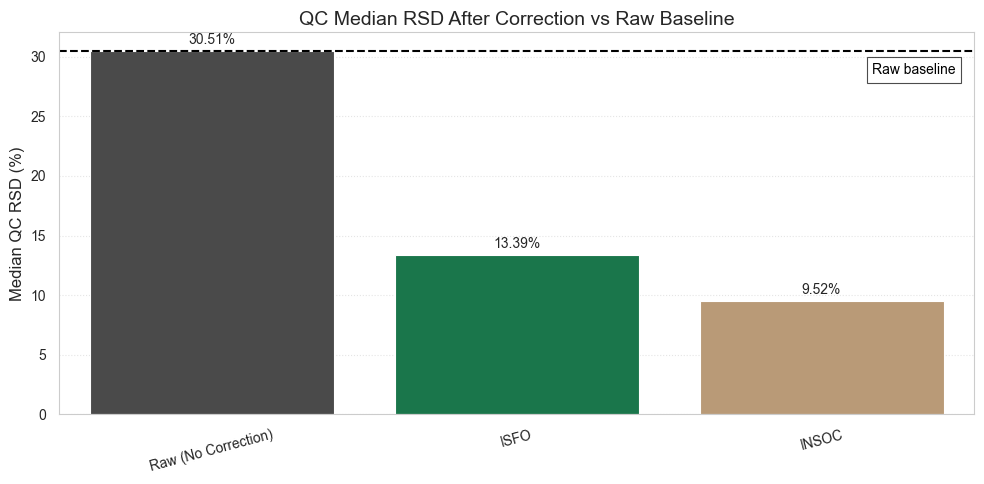

[INFO] Matplotlib figure saved successfully: c:\Users\adria\OneDrive\Escritorio\bueno_ibecp4048\docs\figures\sec3_1_2_pca_by_method_qc3.png


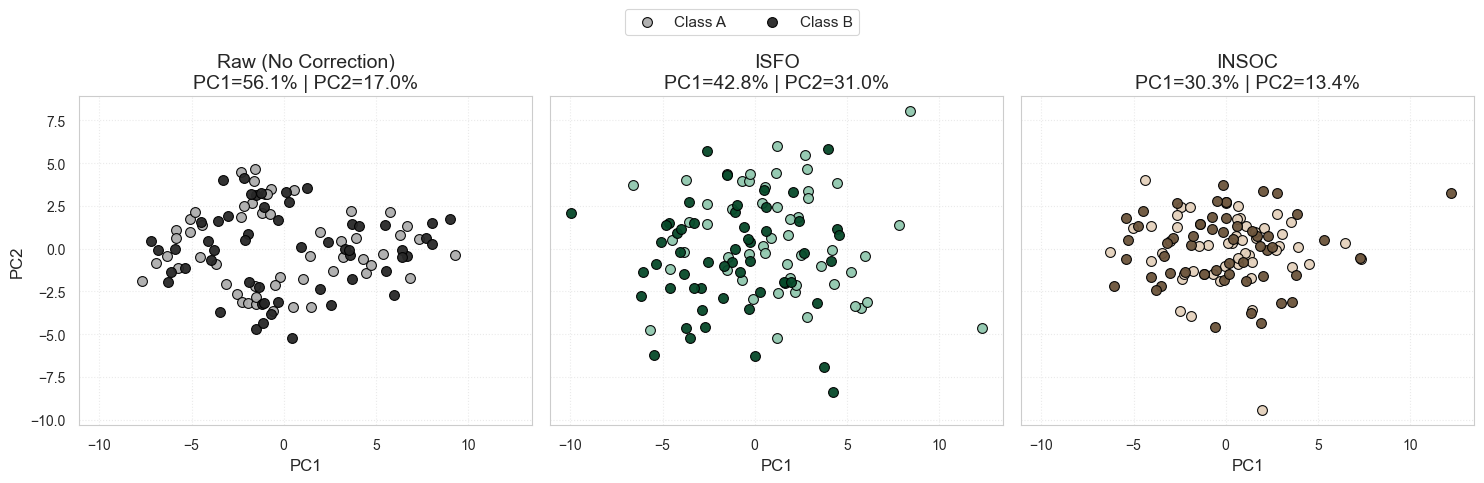

[INFO] Matplotlib figure saved successfully: c:\Users\adria\OneDrive\Escritorio\bueno_ibecp4048\docs\figures\sec3_1_2_pca_by_batch_qc3.png


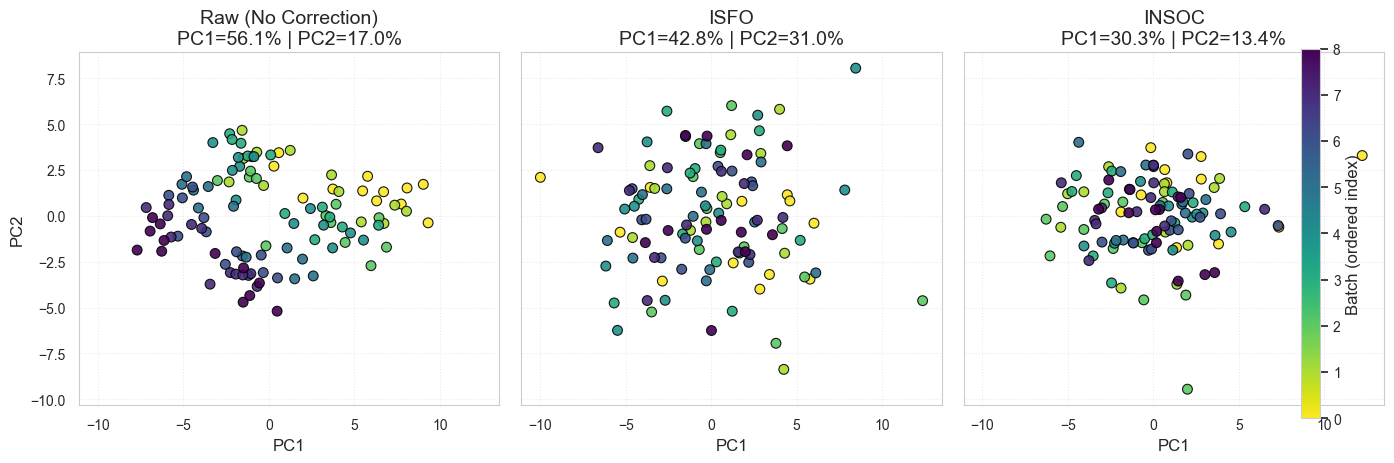

[INFO] Matplotlib figure saved successfully: c:\Users\adria\OneDrive\Escritorio\bueno_ibecp4048\docs\figures\sec3_1_2_pca_by_acq_order_qc3.png


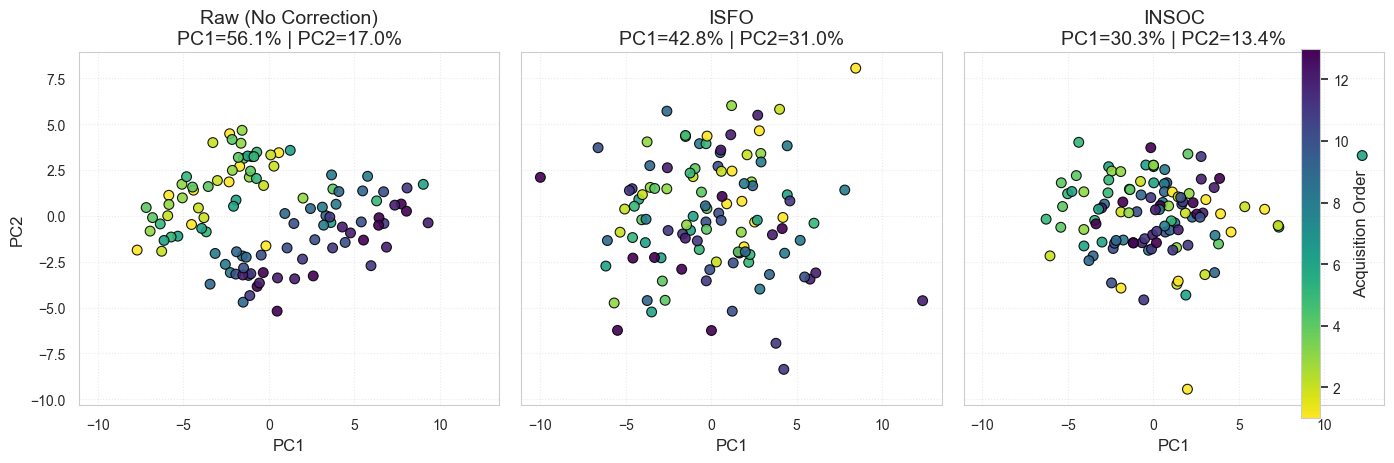

,Method,Median_RSD_QC,Delta_vs_Raw
0,Raw (No Correction),30.510963,0.000000
1,ISFO,13.385479,-17.125484
2,INSOC,9.522632,-20.988331


In [ ]:
# ======================================================================================
# RSD CLEANING + PCA COMPARISON (RAW vs CORE CORRECTION METHODS)
# ======================================================================================

def _apply_correction(model, X_qc, meta_qc, X_pat, meta_pat):
    """Fit one correction model on QC and transform QC + patient matrices."""
    m = deepcopy(model)
    m.fit(X_qc, meta_qc)

    sig = inspect.signature(m.transform).parameters
    if "meta_pat" in sig:
        X_qc_corr = m.transform(X_qc, meta_pat=meta_qc)
        X_pat_corr = m.transform(X_pat, meta_pat=meta_pat)
    elif "meta" in sig:
        X_qc_corr = m.transform(X_qc, meta=meta_qc)
        X_pat_corr = m.transform(X_pat, meta=meta_pat)
    else:
        X_qc_corr = m.transform(X_qc)
        X_pat_corr = m.transform(X_pat)

    return X_qc_corr, X_pat_corr


def calculate_median_rsd_global(X):
    """Median QC RSD helper used by the validation plot and summary table."""
    return np.median(np.std(X, axis=0, ddof=1) / (np.abs(np.mean(X, axis=0)) + 1e-12) * 100)


def evaluate_rsd_cleaning_and_pca(
    X_raw_base,
    batches_base,
    acq_order_base,
    qc_count_per_batch=3,
    effect_size=1.05,
    random_state=42,
    pca_n_components=2,
    pca_feature_cap=60,
    ):
    """
    Evaluate correction methods using:
    1) QC median RSD reduction vs Raw baseline
    2) PCA views to inspect whether batch/time effects are erased while patient structure remains
    """
    
    engine = SimpleClinicalSyntheticGCIMSEngine(
        X_raw=X_raw_base,
        batch_labels=batches_base,
        run_order=acq_order_base,
        qc_count_per_batch=qc_count_per_batch,
        n_biomarkers=1,
        effect_size=effect_size,
        biological_variance=0.10,
        background_noise_std=0.01,
        random_state=random_state
    )
    d = engine.generate()

    X_qc = d["X_qc"]
    X_pat = d["X_patients"]
    y_pat = d["group_labels"]

    meta_qc = pd.DataFrame({
        "batch": d["batch_labels_qc"],
        "acq_order": d["run_order_qc"]
    })
    meta_pat = pd.DataFrame({
        "batch": d["batch_labels_patients"],
        "acq_order": d["run_order_patients"]
    })

    core_models = build_core_correction_models()
    normalized_models = core_models.copy()
    methods_order = ["Raw (No Correction)", "ISFO", "INSOC"]

    method_outputs = {
        "Raw (No Correction)": {
            "X_qc": X_qc,
            "X_pat": X_pat
        }
    }

    for method_name, model in normalized_models.items():
        X_qc_corr, X_pat_corr = _apply_correction(model, X_qc, meta_qc, X_pat, meta_pat)
        method_outputs[method_name] = {
            "X_qc": X_qc_corr,
            "X_pat": X_pat_corr
        }

    rsd_records = []
    rsd_raw = calculate_median_rsd_global(method_outputs["Raw (No Correction)"]["X_qc"])

    for method_name in methods_order:
        rsd_val = calculate_median_rsd_global(method_outputs[method_name]["X_qc"])
        rsd_records.append({
            "Method": method_name,
            "Median_RSD_QC": rsd_val,
            "Delta_vs_Raw": rsd_val - rsd_raw
        })

    df_rsd = pd.DataFrame(rsd_records)
    df_rsd["Method"] = pd.Categorical(df_rsd["Method"], categories=methods_order, ordered=True)
    df_rsd = df_rsd.sort_values("Method").reset_index(drop=True)

    fig_rsd, ax_rsd = plt.subplots(figsize=(10, 5))
    sns.barplot(
        data=df_rsd,
        x="Method",
        y="Median_RSD_QC",
        palette=[COLOR_MAP[m] for m in df_rsd["Method"]],
        ax=ax_rsd
    )
    ax_rsd.axhline(rsd_raw, color="black", linestyle="--", linewidth=1.5)
    apply_consistent_style(ax_rsd, "QC Median RSD After Correction vs Raw Baseline", "", "Median QC RSD (%)")
    ax_rsd.tick_params(axis="x", rotation=15)
    y_range = max(df_rsd["Median_RSD_QC"].max() - df_rsd["Median_RSD_QC"].min(), 1e-6)
    ax_rsd.text(
        0.98,
        rsd_raw - 0.05 * y_range,
        "Raw baseline",
        ha="right",
        va="top",
        fontsize=PLOT_FONT_TICK,
        color="black",
        bbox=dict(facecolor="white", edgecolor="black", linewidth=PLOT_EDGE_WIDTH, alpha=0.7),
        transform=ax_rsd.get_yaxis_transform()
    )
    ax_rsd.grid(axis="y", linestyle=":", alpha=0.5)

    for i, row in df_rsd.iterrows():
        ax_rsd.text(
            i,
            row["Median_RSD_QC"] + 0.3,
            f"{row['Median_RSD_QC']:.2f}%",
            ha="center",
            va="bottom",
            fontsize=PLOT_FONT_TICK
        )

    fig_rsd.tight_layout()
    save_clean_figure(fig_rsd, f"sec3_1_2_rsd_vs_raw_qc{qc_count_per_batch}.png")
    plt.show()

    n_features = X_pat.shape[1]
    feat_cap = min(pca_feature_cap, n_features)

    pca_cache = {}
    for method_name in methods_order:
        X_curr = method_outputs[method_name]["X_pat"][:, :feat_cap]
        X_scaled = StandardScaler().fit_transform(X_curr)
        pca = PCA(n_components=pca_n_components, random_state=42)
        scores = pca.fit_transform(X_scaled)
        pca_cache[method_name] = {
            "scores": scores,
            "evr": pca.explained_variance_ratio_ * 100
        }

    # 2A) PCA: method color with class shading (light vs dark)
    fig_pca_method, axes = plt.subplots(1, len(methods_order), figsize=(5 * len(methods_order), 4.8), sharex=True, sharey=True)
    if len(methods_order) == 1:
        axes = [axes]

    patient_labels = {0: "Class A", 1: "Class B"}

    for ax, method_name in zip(axes, methods_order):
        scores = pca_cache[method_name]["scores"]
        evr = pca_cache[method_name]["evr"]
        base_color = COLOR_MAP[method_name]
        c_light = adjust_color_brightness(base_color, 1.55)
        c_dark = adjust_color_brightness(base_color, 0.55)

        for group_val, c in zip([0, 1], [c_light, c_dark]):
            mask = (y_pat == group_val)
            ax.scatter(
                scores[mask, 0],
                scores[mask, 1],
                s=50,
                alpha=0.95,
                c=c,
                edgecolors="black",
                linewidths=PLOT_EDGE_WIDTH,
                label=patient_labels[group_val] if method_name == "Raw (No Correction)" else None
            )

        apply_consistent_style(
            ax,
            f"{method_name}\nPC1={evr[0]:.1f}% | PC2={evr[1]:.1f}%",
            "PC1",
            "PC2" if method_name == methods_order[0] else "",
        )
        ax.grid(linestyle=":", alpha=0.4)

    handles, labels = axes[0].get_legend_handles_labels()
    fig_pca_method.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)
    fig_pca_method.tight_layout(rect=[0, 0, 1, 0.95])
    save_clean_figure(fig_pca_method, f"sec3_1_2_pca_by_method_qc{qc_count_per_batch}.png")
    plt.show()

    # 2B) PCA: color by batch
    fig_pca_batch, axes = plt.subplots(1, len(methods_order), figsize=(5 * len(methods_order), 4.8), sharex=True, sharey=True)
    if len(methods_order) == 1:
        axes = [axes]

    batch_vals = meta_pat["batch"].values
    batch_numeric = pd.factorize(batch_vals)[0].astype(float)
    batch_norm = plt.Normalize(vmin=np.min(batch_numeric), vmax=np.max(batch_numeric) if np.max(batch_numeric) > 0 else 1)
    batch_cmap = plt.cm.viridis_r

    for ax, method_name in zip(axes, methods_order):
        scores = pca_cache[method_name]["scores"]
        evr = pca_cache[method_name]["evr"]

        ax.scatter(
            scores[:, 0],
            scores[:, 1],
            s=50,
            alpha=0.90,
            c=batch_numeric,
            cmap=batch_cmap,
            norm=batch_norm,
            edgecolors="black",
            linewidths=PLOT_EDGE_WIDTH,
        )
        apply_consistent_style(
            ax,
            f"{method_name}\nPC1={evr[0]:.1f}% | PC2={evr[1]:.1f}%",
            "PC1",
            "PC2" if method_name == methods_order[0] else "",
        )
        ax.grid(linestyle=":", alpha=0.4)

    cbar_batch = fig_pca_batch.colorbar(
        plt.cm.ScalarMappable(norm=batch_norm, cmap=batch_cmap),
        ax=axes.tolist(),
        fraction=0.035,
        pad=0.02
    )
    cbar_batch.set_label("Batch (ordered index)", fontsize=PLOT_FONT_LABEL)
    fig_pca_batch.tight_layout(rect=[0, 0, 0.94, 1.0])
    save_clean_figure(fig_pca_batch, f"sec3_1_2_pca_by_batch_qc{qc_count_per_batch}.png")
    plt.show()

    # 2C) PCA: color by acquisition order
    fig_pca_acq, axes = plt.subplots(1, len(methods_order), figsize=(5 * len(methods_order), 4.8), sharex=True, sharey=True)
    if len(methods_order) == 1:
        axes = [axes]

    acq_vals = meta_pat["acq_order"].values
    norm_acq = plt.Normalize(vmin=np.min(acq_vals), vmax=np.max(acq_vals))
    cmap_acq = plt.cm.viridis_r

    for ax, method_name in zip(axes, methods_order):
        scores = pca_cache[method_name]["scores"]
        evr = pca_cache[method_name]["evr"]

        ax.scatter(
            scores[:, 0],
            scores[:, 1],
            s=50,
            alpha=0.90,
            c=acq_vals,
            cmap=cmap_acq,
            norm=norm_acq,
            edgecolors="black",
            linewidths=PLOT_EDGE_WIDTH,
        )
        apply_consistent_style(
            ax,
            f"{method_name}\nPC1={evr[0]:.1f}% | PC2={evr[1]:.1f}%",
            "PC1",
            "PC2" if method_name == methods_order[0] else "",
        )
        ax.grid(linestyle=":", alpha=0.4)

    cbar = fig_pca_acq.colorbar(plt.cm.ScalarMappable(norm=norm_acq, cmap=cmap_acq), ax=axes.tolist(), fraction=0.035, pad=0.02)
    cbar.set_label("Acquisition Order", fontsize=PLOT_FONT_LABEL)
    fig_pca_acq.tight_layout(rect=[0, 0, 0.94, 1.0])
    save_clean_figure(fig_pca_acq, f"sec3_1_2_pca_by_acq_order_qc{qc_count_per_batch}.png")
    plt.show()

    return df_rsd, method_outputs


# Execution for default QC layout (3 QCs per batch)
df_rsd_validation, method_outputs_validation = evaluate_rsd_cleaning_and_pca(
    X_raw_base=X_raw,
    batches_base=batches,
    acq_order_base=meta_df[time_col].values,
    qc_count_per_batch=3,
    effect_size=1.05,
    random_state=42,
    )

df_rsd_validation

### 3.2 Default Configuration Data Generation

#### 3.2.1 Data generation with default parameters

In [ ]:
# Default Configuration
DEFAULT_CONFIG = dict(
    qc_count_per_batch=3,             # Exactly 3 QCs per batch (leaving 6 A's and 6 B's per batch)
    n_biomarkers=1,                   # Modifying a signature of 1 feature
    effect_size=1.05,                 # Multiplicative Fold Change 'k'=1.05 (Group A: *1.05, Group B: /1.05)
    biological_variance=0.10,         # 10% patient-to-patient variance 
    background_noise_std=0.01,        # Very small Gaussian noise added to non-biomarker features
    target_feature_idx=11,            # Fixed default target feature as requested
    random_state=42,
 )

# Initialize the engine passing the empirical base data
engine = SimpleClinicalSyntheticGCIMSEngine(
    X_raw=X_raw,
    batch_labels=batches,
    run_order=meta_df[time_col].values,
    **DEFAULT_CONFIG
)

# Generate the coupled semi-synthetic data matrix
d_default = engine.generate()

# Extract reference matrices
X_full      = d_default["X"]
X_qc        = d_default["X_qc"]
X_patients  = d_default["X_patients"]
y_patients  = d_default["group_labels"]     # 0 = Patient A, 1 = Patient B

# Build metadata dataframes to feed the inductive correction models
# (Crucial for SERRF and LOESS which need the temporal domain)
meta_qc = pd.DataFrame({
    "batch":     d_default["batch_labels_qc"],
    "acq_order": d_default["run_order_qc"],
})

meta_patients = pd.DataFrame({
    "batch":     d_default["batch_labels_patients"],
    "acq_order": d_default["run_order_patients"],
})

print(f"Data generated successfully with Multiplicative Effect Size (k) = {DEFAULT_CONFIG['effect_size']}")

# Extract metadata dictionary from the generated payload
metrics = d_default["spike_metadata"]

print("═" * 70)
print("  GENERATED DATA SUMMARY")
print("═" * 70)
print(f"  Total acquisitions     : {engine.N}")
print(f"  QC samples             : {len(d_default['qc_indices'])}  ({engine.qc_count}/batch)")
print(f"  Patient samples        : {len(d_default['patient_indices'])}  "
      f"(A={int((y_patients==0).sum())}, B={int((y_patients==1).sum())})")
print(f"  Features (p)           : {engine.P} (Active Biomarkers: {metrics['n_biomarkers']})")
print(f"  n_batches              : {len(np.unique(engine.batch_labels))}")
print("─" * 70)
print(f"  Spike Effect Size      : {metrics['effect_size']:.2f} AU")
print(f"  Biological Variance    : {metrics['biological_variance']:.2%} of Effect Size")
print(f"  Background Noise Std   : {metrics['background_noise_std']:.2%} of Effect Size")
print(f"  Active Feature Indices : {metrics['active_features']}")
print("═" * 70)

Data generated successfully with Multiplicative Effect Size (k) = 1.05
══════════════════════════════════════════════════════════════════════
  GENERATED DATA SUMMARY
══════════════════════════════════════════════════════════════════════
  Total acquisitions     : 135
  QC samples             : 27  (3/batch)
  Patient samples        : 108  (A=54, B=54)
  Features (p)           : 31 (Active Biomarkers: 1)
  n_batches              : 9
──────────────────────────────────────────────────────────────────────
  Spike Effect Size      : 1.05 AU
  Biological Variance    : 10.00% of Effect Size
  Background Noise Std   : 1.00% of Effect Size
  Active Feature Indices : [11]
══════════════════════════════════════════════════════════════════════


In [9]:
# Visualization for the generated data

def plot_hybrid_spike_diagnostics(data_dict, batches, acq_orders, target_feature_idx=None):
    """
    Generates 3 diagnostic visualizations for the semi-synthetic GC-IMS matrices.
    
    Parameters:
    - data_dict: The dictionary resulting from engine.generate()
    - batches: The original array mapped with the batch labels (N,)
    - acq_orders: The original array mapped with the acquisition order identifiers (N,)
    - target_feature_idx: Targeted active biomarker to observe (defaults to the first active instance found).
    """
    metrics = data_dict["spike_metadata"]
    active_feats = metrics["active_features"]
    
    if target_feature_idx is None:
        target_feature_idx = 11 if 11 < data_dict["X"].shape[1] else 0
            
    X_spiked = data_dict["X"]
    X_raw = data_dict["X_raw_baseline"]
    group_col = data_dict["group_col"]
    
    lexsort_idx = np.lexsort((acq_orders, batches))
    
    fig = plt.figure(figsize=(18, 14))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1])
    
    ax0 = fig.add_subplot(gs[0, :])
    
    x_axis = np.arange(len(lexsort_idx))
    f_spiked = X_spiked[:, target_feature_idx][lexsort_idx]
    f_raw = X_raw[:, target_feature_idx][lexsort_idx]
    g_sorted = group_col[lexsort_idx]
    
    ax0.plot(x_axis, f_raw, color='gray', alpha=0.5, linestyle='--', label='Raw Empirical Baseline')
    ax0.plot(x_axis, f_spiked, color='black', alpha=0.2, zorder=1)
    
    mask_qc = g_sorted == "QC"
    mask_A = g_sorted == "A"
    mask_B = g_sorted == "B"
    
    ax0.scatter(x_axis[mask_qc], f_spiked[mask_qc], c='#1f77b4', s=60, marker='s', label='QC', zorder=3)
    ax0.scatter(x_axis[mask_A], f_spiked[mask_A], c='#2ca02c', s=60, marker='^', label='Patient A', zorder=3)
    ax0.scatter(x_axis[mask_B], f_spiked[mask_B], c='#d62728', s=60, marker='v', label='Patient B', zorder=3)
    
    b_sorted = batches[lexsort_idx]
    batch_changes = np.where(b_sorted[:-1] != b_sorted[1:])[0]
    for b in batch_changes:
        ax0.axvline(x=b + 0.5, color='black', linestyle=':', alpha=0.3)
        
    status = "ACTIVE BIOMARKER" if target_feature_idx in active_feats else "BACKGROUND FEATURE"
    apply_consistent_style(
        ax0,
        f"1. Temporal Drift & Batch Effects | Feature {target_feature_idx} ({status})",
        "Acquisition Sequence (Sorted by Batch & Acquisition Order)",
        "Intensity (AU)",
    )
    ax0.legend(loc='upper right')
    ax0.grid(axis='y', linestyle='--', alpha=0.4)

    ax1 = fig.add_subplot(gs[1, 0])
    idx_A = np.where(group_col == "A")[0][0]
    idx_B = np.where(group_col == "B")[0][0]
    features_axis = np.arange(X_spiked.shape[1])
    
    ax1.plot(features_axis, X_raw[idx_A, :], color='gray', alpha=0.4, linestyle='-', label='Raw Baseline')
    ax1.plot(features_axis, X_spiked[idx_A, :], color='#2ca02c', alpha=0.8, marker='^', label='Spiked Patient A')
    ax1.plot(features_axis, X_spiked[idx_B, :], color='#d62728', alpha=0.8, marker='v', label='Spiked Patient B')
    
    for feat in active_feats:
        ax1.axvline(x=feat, color='purple', alpha=0.2, linewidth=8)
        
    apply_consistent_style(ax1, "2. Full Spectrum Profile: Pre- vs Post-Injection", "Feature Index (0 to 30)", "Intensity (AU)")
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.4)

    ax2 = fig.add_subplot(gs[1, 1])
    df_box = pd.DataFrame({
        "Intensity": X_spiked[:, target_feature_idx],
        "Group": group_col
    })
    df_box["Group"] = pd.Categorical(df_box["Group"], categories=["QC", "A", "B"], ordered=True)
    
    sns.boxplot(data=df_box, x="Group", y="Intensity", ax=ax2, 
                palette={"QC": "#1f77b4", "A": "#2ca02c", "B": "#d62728"}, 
                boxprops=dict(alpha=0.6, linewidth=PLOT_EDGE_WIDTH))
    sns.stripplot(data=df_box, x="Group", y="Intensity", ax=ax2, 
                  color='black', alpha=0.5, jitter=True)
    
    apply_consistent_style(ax2, f"3. Clinical Variance Distribution | Feature {target_feature_idx}", "", "Intensity (AU)")
    ax2.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    save_clean_figure(fig, f"sec3_2_hybrid_spike_diagnostics_feat{target_feature_idx}.png")
    plt.show()

# Execution
# plot_hybrid_spike_diagnostics(d_default, batches, meta_df[time_col].values, target_feature_idx=11)

### 3.3 Classification Task Evaluation

#### 3.3.1 OPAT (One Parameter at a Time) Analysis

In [ ]:
# ======================================================================================
# OPAT SWEEP (PARALLELIZED OVER 31 FEATURES)
# ======================================================================================


COMMON_ANCHOR = {
    "qc_count_per_batch": 3,
    "n_biomarkers": 1,
    "effect_size": 1.05,
    "biological_variance": 0.1,
    "background_noise_std": 0.01,
    "random_state": 42
}

# Keep only effect_size as varying parameter, explicitly including baseline 1.0
effect_size_geom = np.round(np.unique(np.concatenate(([1.0], 1.0 + np.geomspace(0.01, 0.4, 10)))), 4)

PARAM_SWEEPS = {
    "effect_size": {"vals": effect_size_geom, "display": effect_size_geom, "name": "Effect Size"},
}

clf_styles = {
    "PLS-DA": {"color": "#d62728", "linestyle": ":", "marker": "v"},
}

SWEEP_PARAMETERS = ["effect_size"]

def _opat_worker(param_key, val, display_val, feature_idx, anchor, X_raw, batches, acq_order, clfs_dict):
    """
    Evaluates a single point in the OPAT grid for a specific target feature.
    """
    current_params = anchor.copy()
    current_params[param_key] = val
    current_params["target_feature_idx"] = feature_idx
    current_params["random_state"] = 42
        
    eng = SimpleClinicalSyntheticGCIMSEngine(
        X_raw=X_raw, batch_labels=batches, run_order=acq_order, **current_params
    )
    data = eng.generate()
    X_pat, y_pat, groups_pat = data["X_patients"], data["group_labels"], data["batch_labels_patients"]
    
    logo = LeaveOneGroupOut()
    res = []
    
    for clf_name, clf in clfs_dict.items():
        cv_res = cross_validate(
            clf, X_pat, y_pat, groups=groups_pat, cv=logo, 
            scoring={"roc_auc": "roc_auc"}, 
            n_jobs=1,
            error_score='raise'
        )
        res.append({
            "Parameter": param_key, 
            "Display_Value": display_val, 
            "Classifier": clf_name,
            "Target_Feature": feature_idx,
            "AUC": cv_res["test_roc_auc"].mean()
        })
    return res

def run_multi_clf_opat_exhaustive(X_raw, batches, acq_order, clfs_dict):
    print(f"\n{'='*75}\n EXECUTING EXHAUSTIVE CLF OPAT (31 FEATURES PER POINT)\n{'='*75}")
    
    anchor = COMMON_ANCHOR.copy()
    P_total = X_raw.shape[1]
    tasks = []
    
    for param_key in SWEEP_PARAMETERS:
        sweep_def = PARAM_SWEEPS[param_key]
        for val, display_val in zip(sweep_def["vals"], sweep_def["display"]):
            for feat_idx in range(P_total):
                tasks.append((param_key, val, display_val, feat_idx))
                
    print(f"[INFO] Dispatched {len(tasks)} independent evaluations. Processing in parallel...")
    
    raw_results = Parallel(n_jobs=-1)(
        delayed(_opat_worker)(
            p_key, v, d_val, f_idx, anchor, X_raw, batches, acq_order, clfs_dict
        ) for p_key, v, d_val, f_idx in tasks
    )
    
    df_opat = pd.DataFrame([item for sublist in raw_results for item in sublist])
    print("\nOPAT Generation Complete.")
    
    return df_opat

# Execution
clfs = build_classifiers(pls_components=2)
df_opat_full = run_multi_clf_opat_exhaustive(X_raw, batches, meta_df[time_col].values, clfs)


[INFO] Matplotlib figure saved successfully: c:\Users\adria\OneDrive\Escritorio\bueno_ibecp4048\docs\figures\sec3_3_1_opat_comprehensive_bounds.png


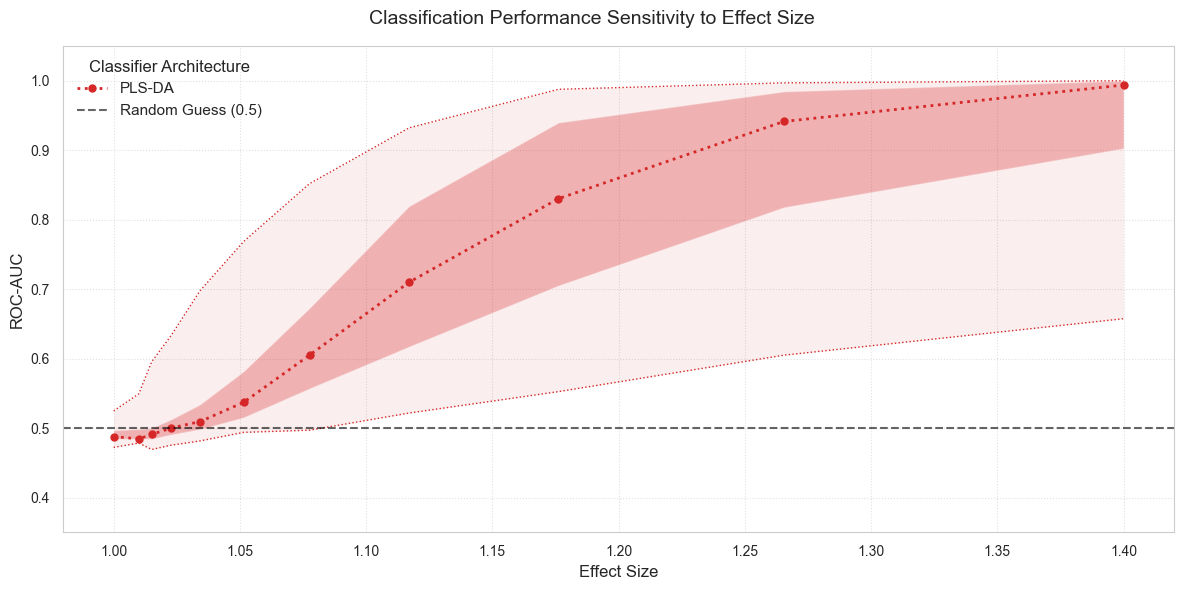

In [34]:
# ======================================================================================
# OPAT VISUALIZATION (MIN, MAX, MEDIAN, IQR)
# ======================================================================================

def plot_opat_comprehensive_bounds(df_opat):
    params = SWEEP_PARAMETERS
    n_params = len(params)
    cols = 1
    rows = n_params
    
    fig, axes = plt.subplots(rows, cols, figsize=(12, 6 * rows))
    if n_params == 1:
        axes = [axes]
    sns.set_theme(style="whitegrid")

    for i, param in enumerate(params):
        ax = axes[i]
        df_plot = df_opat[df_opat["Parameter"] == param]
        
        stats = df_plot.groupby(["Classifier", "Display_Value"])["AUC"].agg(
            Median='median',
            Q25=lambda x: x.quantile(0.25),
            Q75=lambda x: x.quantile(0.75),
            Min='min',
            Max='max'
        ).reset_index()
        
        for clf_name in stats["Classifier"].unique():
            if clf_name not in clf_styles:
                continue
            clf_data = stats[stats["Classifier"] == clf_name].sort_values("Display_Value")
            style = clf_styles[clf_name]
            x_vals = clf_data["Display_Value"]
            
            ax.plot(x_vals, clf_data["Median"], label=clf_name, color=style["color"],
                    linewidth=2.0, linestyle=style.get("linestyle", "-"), marker="o", markersize=5)
            ax.fill_between(x_vals, clf_data["Q25"], clf_data["Q75"],
                            color=style["color"], alpha=0.3, edgecolor=None)
            ax.fill_between(x_vals, clf_data["Min"], clf_data["Max"],
                            color=style["color"], alpha=0.08, edgecolor=None)
            ax.plot(x_vals, clf_data["Min"], color=style["color"], linewidth=1.0, linestyle=':')
            ax.plot(x_vals, clf_data["Max"], color=style["color"], linewidth=1.0, linestyle=':')
            
        ax.axhline(0.5, color="black", linestyle="--", alpha=0.6, label="Random Guess (0.5)")
        apply_consistent_style(ax, None, PARAM_SWEEPS[param]["name"], "ROC-AUC")
        ax.set_ylim(0.35, 1.05)
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(title="Classifier Architecture", loc='upper left')

    plt.suptitle("Classification Performance Sensitivity to Effect Size", fontsize=PLOT_FONT_TITLE, y=0.98)
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    save_clean_figure(fig, "sec3_3_1_opat_comprehensive_bounds.png")
    plt.show()


def plot_sensitivity_analysis(df_opat):
    """Computes and plots the Sensitivity (Slope) of AUC w.r.t effect_size for each feature."""
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    df_sub = df_opat[df_opat["Parameter"] == "effect_size"]
    sensitivities = []
    for feat in df_sub["Target_Feature"].unique():
        data = df_sub[df_sub["Target_Feature"] == feat].sort_values("Display_Value")
        slope, _, r_val, _, _ = linregress(data["Display_Value"], data["AUC"])
        sensitivities.append({
            "Target_Feature": feat,
            "Slope": slope,
            "R2": r_val**2
        })
    
    df_sens = pd.DataFrame(sensitivities).sort_values("Slope", ascending=False)
    sns.barplot(data=df_sens, x="Target_Feature", y="Slope", palette="viridis", ax=ax)
    apply_consistent_style(ax, "Sensitivity Analysis: Effect Size", "Target Feature Index", "AUC Sensitivity (Slope)")
    ax.axhline(0, color='red', linestyle='--', alpha=0.5)

    plt.tight_layout()
    save_clean_figure(fig, "sec3_3_1_sensitivity_analysis.png")
    plt.show()
    
    return df_sens


plot_opat_comprehensive_bounds(df_opat_full)
#df_sens_effect = plot_sensitivity_analysis(df_opat_full)

#### 3.3.2 Classification task pre vs post correction with default parameters

In [10]:

def _calculate_rsd(X):
    """Helper to calculate Median RSD percentage."""
    return np.median(np.std(X, axis=0, ddof=1) / (np.abs(np.mean(X, axis=0)) + 1e-12) * 100)

def _process_one_feature_with_rsd(feat_idx, X_raw, batches, acq_order, correction_models, classifiers, effect_size):
    """
    Evaluates a single feature for Predictive Power (LOGO CV AUC) 
    and Technical/Biological Precision (RSD QC & RSD Patient).
    """
    # 1. Data engine
    engine = SimpleClinicalSyntheticGCIMSEngine(
        X_raw=X_raw, batch_labels=batches, run_order=acq_order,
        qc_count_per_batch=3, n_biomarkers=1, effect_size=effect_size,
        biological_variance=0.10, background_noise_std=0.01, 
        target_feature_idx=feat_idx, random_state=42
    )
    d = engine.generate()
    
    meta_qc = pd.DataFrame({"batch": d["batch_labels_qc"], "acq_order": d["run_order_qc"]})
    meta_pat = pd.DataFrame({"batch": d["batch_labels_patients"], "acq_order": d["run_order_patients"]})
    X_qc, X_pat = d["X_qc"], d["X_patients"]
    
    # ¡SOLUCIÓN! Definimos all_methods ANTES de evaluar la predicción
    all_methods = {"Raw (No Correction)": None, **correction_models}
    
    # 2. Evaluate Predictive Metrics (LOGO CV)
    df_run = evaluate_inductive_logo(
        X_pat, d["group_labels"], d["batch_labels_patients"],
        X_qc, meta_qc, d["batch_labels_qc"],
        all_methods, classifiers, meta_pat  # <--- Ahora le pasamos all_methods, incluyendo Raw
    )
    
    # 3. Evaluate Technical vs Biological Variance (Global Fit)
    rsd_records = []
    
    for method_name, model in all_methods.items():
        if model is None:
            X_qc_corr, X_pat_corr = X_qc, X_pat
        else:
            m_clone = deepcopy(model)
            m_clone.fit(X_qc, meta_qc)
            
            sig = inspect.signature(m_clone.transform).parameters
            if 'meta_pat' in sig:
                X_qc_corr = m_clone.transform(X_qc, meta_pat=meta_qc)
                X_pat_corr = m_clone.transform(X_pat, meta_pat=meta_pat)
            elif 'meta' in sig:
                X_qc_corr = m_clone.transform(X_qc, meta=meta_qc)
                X_pat_corr = m_clone.transform(X_pat, meta=meta_pat)
            else:
                X_qc_corr = m_clone.transform(X_qc)
                X_pat_corr = m_clone.transform(X_pat)
        
        # Calculate QCs (Technical Variance)
        rsd_qc_median = _calculate_rsd(X_qc_corr)
        rsd_qc_tgt = (np.std(X_qc_corr[:, feat_idx], ddof=1) / (np.abs(np.mean(X_qc_corr[:, feat_idx])) + 1e-12)) * 100
        
        # Calculate Patients (Biological + Technical Variance)
        rsd_pat_median = _calculate_rsd(X_pat_corr)
        rsd_pat_tgt = (np.std(X_pat_corr[:, feat_idx], ddof=1) / (np.abs(np.mean(X_pat_corr[:, feat_idx])) + 1e-12)) * 100
        
        rsd_records.append({
            "Correction": method_name,
            "RSD_QC_Median": rsd_qc_median,
            "RSD_QC_Target": rsd_qc_tgt,
            "RSD_Pat_Median": rsd_pat_median,
            "RSD_Pat_Target": rsd_pat_tgt
        })
        
    df_rsd = pd.DataFrame(rsd_records)
    
    # 4. Merge Classification & Variance Metrics
    df_merged = pd.merge(df_run, df_rsd, on="Correction")
    df_merged["Feature_Idx"] = feat_idx
    
    return df_merged


def evaluate_plsda_aggregated_all_features(X_raw, batches, acq_order, correction_models, classifiers, effect_size=1.05):
    print(f"[INFO] Running Aggregated LOGO Evaluation across {X_raw.shape[1]} features (Parallelized)...")
    
    all_feature_results = Parallel(n_jobs=-1)(
        delayed(_process_one_feature_with_rsd)(
            feat_idx, X_raw, batches, acq_order, correction_models, classifiers, effect_size
        ) for feat_idx in range(X_raw.shape[1])
    )
    
    df_all = pd.concat(all_feature_results, ignore_index=True)
    
    # Summary
    numeric_cols = ["ROC-AUC", "Accuracy", "RSD_QC_Median", "RSD_QC_Target"]
    agg_summary = df_all.groupby(["Correction", "Classifier"])[numeric_cols].mean().round(3)
    
    print("\n" + "="*80)
    print(f" AGGREGATED METRICS SUMMARY (MEAN ACROSS {X_raw.shape[1]} FEATURES)")
    print("="*80)
    print(agg_summary.to_string())
    print("="*80)
    
    return df_all, agg_summary

# Execution
correction_models = build_correction_models()
classifiers = build_classifiers(pls_components=2)

df_all_metrics_clf_defaultparams, agg_summary = evaluate_plsda_aggregated_all_features(
    X_raw, batches, meta_df[time_col].values, correction_models, classifiers, effect_size=1.05
)

[INFO] Running Aggregated LOGO Evaluation across 31 features (Parallelized)...

 AGGREGATED METRICS SUMMARY (MEAN ACROSS 31 FEATURES)
                                ROC-AUC  Accuracy  RSD_QC_Median  RSD_QC_Target
Correction          Classifier                                                 
INSOC               PLS-DA        0.589     0.556          9.523         16.023
ISFO                PLS-DA        0.617     0.574         13.385         17.863
LOESSCorrector      PLS-DA        0.559     0.531         24.187         30.706
Raw (No Correction) PLS-DA        0.564     0.528         30.511         35.409
SERRFCorrector      PLS-DA        0.571     0.536         21.964         26.647


In [36]:
# Classification improvement results visualization

def prepare_delta_metrics(df_all_metrics):
    """
    Computes Delta AUC and Delta RSD and strictly guarantees a Raw baseline 
    row per feature so the boxplot shows all 5 methods (Raw + 4 correction methods).
    """
    df = df_all_metrics.copy()

    # 1. Detect which naming convention your dataset uses for the Raw columns
    if {'AUC_Raw_Mean', 'RSD_QC_Raw'}.issubset(df.columns):
        raw_auc_col = 'AUC_Raw_Mean'
        raw_rsd_col = 'RSD_QC_Raw'
    elif {'Raw_AUC', 'Raw_RSD'}.issubset(df.columns):
        raw_auc_col = 'Raw_AUC'
        raw_rsd_col = 'Raw_RSD'
    else:
        raw_auc_col = None
        raw_rsd_col = None

    # 2. If Raw columns exist, calculate Deltas and RECONSTRUCT the Raw rows
    if raw_auc_col and raw_rsd_col:
        df['Delta_AUC'] = df['ROC-AUC'] - df[raw_auc_col]
        df['Delta_RSD'] = df['RSD_QC_Target'] - df[raw_rsd_col]
        
        # Reconstruct the Raw baseline rows if they are missing from the 'Correction' column
        if not (df['Correction'] == 'Raw (No Correction)').any():
            raw_rows = (
                df[['Feature_Idx', raw_auc_col, raw_rsd_col]]
                .dropna()
                .drop_duplicates()
                .rename(columns={raw_auc_col: 'ROC-AUC', raw_rsd_col: 'RSD_QC_Target'})
            )
            raw_rows['Correction'] = 'Raw (No Correction)'
            raw_rows['Delta_AUC'] = 0.0
            raw_rows['Delta_RSD'] = 0.0
            df = pd.concat([df, raw_rows], ignore_index=True, sort=False)
            
    # 3. Fallback: If no Raw columns exist, extract them from existing Raw rows
    else:
        raw_baseline = (
            df[df['Correction'] == 'Raw (No Correction)'][['Feature_Idx', 'ROC-AUC', 'RSD_QC_Target']]
            .dropna()
            .drop_duplicates(subset=['Feature_Idx'])
            .rename(columns={'ROC-AUC': 'Raw_AUC', 'RSD_QC_Target': 'Raw_RSD'})
        )
        if not raw_baseline.empty:
            df = df.merge(raw_baseline, on='Feature_Idx', how='left')
            df['Delta_AUC'] = df['ROC-AUC'] - df['Raw_AUC']
            df['Delta_RSD'] = df['RSD_QC_Target'] - df['Raw_RSD']

    # 4. Enforce exactly 0.0 for the Deltas of the Raw rows to prevent plotting artifacts
    raw_mask = df['Correction'] == 'Raw (No Correction)'
    if 'Delta_AUC' in df.columns:
        df.loc[raw_mask, 'Delta_AUC'] = 0.0
    if 'Delta_RSD' in df.columns:
        df.loc[raw_mask, 'Delta_RSD'] = 0.0

    return df


# ======================================================================================
# INDEPENDENT PLOTTING FUNCTIONS
# ======================================================================================

def _compute_fdr_auc_threshold(df, auc_col='ROC-AUC', alpha=0.05):
    """One-sided test H0: AUC=0.5 with BH-FDR correction over all points."""
    if 'y_patients' in globals():
        y_local = np.asarray(y_patients)
        n_pos = int(np.sum(y_local == 1))
        n_neg = int(np.sum(y_local == 0))
    else:
        n_pos, n_neg = 54, 54

    # CORRECTED: Hanley & McNeil formula for AUC standard error under the null hypothesis
    se0 = np.sqrt((n_pos + n_neg + 1.0) / (12.0 * n_pos * n_neg))
    
    auc_values = df[auc_col].to_numpy(dtype=float)
    z_scores = (auc_values - 0.5) / se0
    pvals = 1.0 - norm.cdf(z_scores)
    rejected, _ = fdrcorrection(pvals, alpha=alpha, method='indep')

    if np.any(rejected):
        threshold = float(np.min(auc_values[rejected]))
    else:
        threshold = 1.0

    count_above = int(np.sum(auc_values >= threshold)) if threshold < 1.0 else 0
    return threshold, count_above, se0, len(auc_values)


def plot_auc_distribution(df):
    fig = go.Figure()
    methods = ['Raw (No Correction)', 'ISFO', 'INSOC', 'LOESSCorrector', 'SERRFCorrector']
    methods = [m for m in methods if m in df['Correction'].unique()]
    
    for method in methods:
        data = df[df['Correction'] == method]
        if data.empty:
            continue
        fig.add_trace(go.Box(
            y=data['ROC-AUC'], name=method, boxpoints='all', jitter=0.3,
            marker_color=COLOR_MAP.get(method, '#333333')
        ))

    threshold, count_above, se0, n_points = _compute_fdr_auc_threshold(df, auc_col='ROC-AUC', alpha=0.05)
    
    if threshold < 1.0:
        fig.add_hline(
            y=threshold, line_dash='dash', line_color='black',
            annotation_text=f'FDR critical AUC = {threshold:.3f}',
            annotation=dict(x=1.02, xanchor='left', font=dict(color='black')) 
        )
    
    apply_plotly_consistent_style(fig, "AUC Distribution by Method", None, "ROC-AUC")
    
    # Añadimos un pequeño margen derecho (margin=dict(r=160)) para evitar que el texto se corte
    fig.update_layout(height=500, margin=dict(r=160))
    
    save_clean_plotly(fig, "sec3_3_2_auc_distribution_by_method")
    fig.show()

    print(f"[FDR] Null SE (AUC=0.5): {se0:.5f} | Points tested: {n_points}")
    if threshold < 1.0:
        print(f"[FDR] Critical AUC threshold: {threshold:.4f}")
    else:
        print("[FDR] No points reached significance after BH correction at alpha=0.05.")

def plot_feature_auc_bars(df):
    fig = go.Figure()
    methods = ['Raw (No Correction)', 'ISFO', 'INSOC', 'LOESSCorrector', 'SERRFCorrector']
    methods = [m for m in methods if m in df['Correction'].unique()]
    
    for method in methods:
        data = df[df['Correction'] == method].sort_values("Feature_Idx")
        if data.empty:
            continue
        fig.add_trace(go.Bar(
            x=data['Feature_Idx'], y=data['ROC-AUC'], name=method,
            marker_color=COLOR_MAP.get(method, '#333333')
        ))
        
    all_features = sorted(df['Feature_Idx'].unique())
    fig.update_layout(
        barmode='group', height=500,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )
    fig.update_yaxes(title_text="ROC-AUC", range=[0.3, 0.8])
    fig.update_xaxes(title_text="Target Feature Index", tickmode='array', tickvals=all_features)
    apply_plotly_consistent_style(fig, "Classification Performance by Target Feature", "Target Feature Index", "ROC-AUC")
    save_clean_plotly(fig, "sec3_3_2_feature_auc_bars")
    fig.show()


def plot_target_rsd_vs_auc(df):
    fig = go.Figure()
    methods = ['Raw (No Correction)', 'ISFO', 'INSOC', 'LOESSCorrector', 'SERRFCorrector']
    methods = [m for m in methods if m in df['Correction'].unique()]
    for method in methods:
        data = df[df['Correction'] == method]
        if data.empty:
            continue
        fig.add_trace(go.Scatter(
            x=data['RSD_QC_Target'], y=data['ROC-AUC'], mode='markers', name=method,
            marker=dict(color=COLOR_MAP.get(method, '#333333'), size=9, opacity=0.8),
            hovertemplate="Feature: %{customdata}<br>Target RSD: %{x:.2f}%<br>AUC: %{y:.3f}<extra></extra>",
            customdata=data['Feature_Idx']
        ))
    apply_plotly_consistent_style(fig, "Feature-Specific Precision vs. Accuracy (Target RSD vs. AUC)", "Target Feature RSD QC (%)", "ROC-AUC")
    fig.update_layout(height=500)
    save_clean_plotly(fig, "sec3_3_2_target_rsd_vs_auc")
    fig.show()


def plot_delta_auc_vs_target_rsd(df):
    fig = go.Figure()
    methods = [m for m in df['Correction'].unique() if m != 'Raw (No Correction)']
    
    for method in methods:
        data = df[df['Correction'] == method]
        data = data.replace([np.inf, -np.inf], np.nan).dropna(subset=['Delta_AUC', 'RSD_QC_Target'])
        if data.empty:
            continue
        fig.add_trace(go.Scatter(
            x=data['RSD_QC_Target'], y=data['Delta_AUC'], mode='markers', name=method,
            marker=dict(color=COLOR_MAP.get(method, '#333333'), size=9, opacity=0.8),
            hovertemplate="Feature: %{customdata}<br>Target RSD: %{x:.2f}%<br>Delta AUC: %{y:.3f}<extra></extra>",
            customdata=data['Feature_Idx']
        ))
        
    fig.add_hline(y=0, line_dash="dash", line_color="black", opacity=0.5)
    apply_plotly_consistent_style(fig, "Clinical Rescue vs. Technical Noise (Delta ROC-AUC vs. Target RSD)", "Target Feature RSD QC (%) - Post Correction", "Delta ROC-AUC (vs. Raw)")
    fig.update_layout(height=500)
    save_clean_plotly(fig, "sec3_3_2_delta_auc_vs_target_rsd")
    fig.show()


def plot_delta_rsd_bars(df):
    fig = go.Figure()
    methods = [m for m in df['Correction'].unique() if m != 'Raw (No Correction)']
    
    for method in methods:
        data = df[df['Correction'] == method].sort_values("Feature_Idx")
        data = data.replace([np.inf, -np.inf], np.nan).dropna(subset=['Delta_RSD'])
        if data.empty:
            continue
        fig.add_trace(go.Bar(
            x=data['Feature_Idx'], y=data['Delta_RSD'], name=method,
            marker_color=COLOR_MAP.get(method, '#333333')
        ))
        
    all_features = sorted(df['Feature_Idx'].unique())
    fig.update_layout(
        barmode='group', height=500,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )
    fig.add_hline(y=0, line_color="black", opacity=0.8)
    fig.update_yaxes(title_text="Delta RSD QC (%) -> Negative is better")
    fig.update_xaxes(title_text="Target Feature Index", tickmode='array', tickvals=all_features)
    apply_plotly_consistent_style(fig, "Change in Technical Variance per Feature (Delta RSD vs. Raw)", "Target Feature Index", "Delta RSD QC (%)")
    save_clean_plotly(fig, "sec3_3_2_delta_rsd_bars")
    fig.show()


# ======================================================================================
# EXECUTION WORKFLOW
# ======================================================================================
df_plot = prepare_delta_metrics(df_all_metrics_clf_defaultparams)
plot_auc_distribution(df_plot)
#plot_feature_auc_bars(df_plot)
#plot_target_rsd_vs_auc(df_plot)
#plot_delta_auc_vs_target_rsd(df_plot)
#plot_delta_rsd_bars(df_plot)

[INFO] Plotly figure saved successfully as PNG at 600 DPI: c:\Users\adria\OneDrive\Escritorio\bueno_ibecp4048\docs\figures\sec3_3_2_auc_distribution_by_method.png


[FDR] Null SE (AUC=0.5): 0.05581 | Points tested: 155
[FDR] Critical AUC threshold: 0.6235


#### 3.3.3 Scalability analysis (behaviour with more features or more samples)

##### 3.3.3.1 Scalability samples wise


In [8]:
# ======================================================================================
# GLOBAL LAYOUTS & COLOR MAPPINGS
# ======================================================================================

LAYOUT_PATTERNS = {
    3: ["QC", "A", "B", "A", "B", "A", "B", "QC", "A", "B", "A", "B", "A", "B", "QC"],
    6: ["QC", "A", "B", "A", "B", "QC", "A", "B", "A", "B", "A", "QC", "B", "A", "B", "A", "B", "QC", "A", "B", "A", "B", "A", "QC", "B", "A", "B", "A", "B", "QC"],
    12: ["QC", "A", "B", "A", "B", "QC", "A", "B", "A", "B", "QC", "A", "B", "A", "B", "A", "QC", "B", "A", "B", "A", "QC", "B", "A", "B", "A", "QC", "B", "A", "B", "A", "B", "QC", "A", "B", "A", "B", "QC", "A", "B", "A", "B", "QC", "A", "B", "A", "B", "A", "QC", "B", "A", "B", "A", "QC", "B", "A", "B", "A", "B", "QC"]
}

SCALABILITY_COLORS = {
    'Raw (No Correction)': '#333333',
    'ISFO_135': '#0b854c',
    'ISFO_270': '#2a9d8f',
    'ISFO_540': '#264653',
    'INSOC_135': '#c49a6c',
    'INSOC_270': '#d8b08a',
    'INSOC_540': '#e6c7aa',
}

# ======================================================================================
# DETERMINISTIC INTERPOLATION
# ======================================================================================

def augment_empirical_matrix(X, batches, acq_order, target_samples_per_batch=30):
    """Linearly interpolates empirical batch data to synthetically scale sample sizes."""
    df = pd.DataFrame(X)
    df['batch'] = batches
    df['acq_order'] = acq_order
    
    new_dfs = []
    for b in np.unique(batches):
        b_df = df[df['batch'] == b].sort_values('acq_order')
        orig_len = len(b_df)
        x_orig = np.linspace(0, 1, orig_len)
        x_new = np.linspace(0, 1, target_samples_per_batch)
        
        new_data = {}
        for col in range(X.shape[1]):
            new_data[col] = np.interp(x_new, x_orig, b_df[col].values)
        new_data['batch'] = b
        new_data['acq_order'] = np.interp(x_new, x_orig, b_df['acq_order'].values)
        new_dfs.append(pd.DataFrame(new_data))
        
    aug_df = pd.concat(new_dfs, ignore_index=True)
    X_aug = aug_df[range(X.shape[1])].values
    return X_aug, aug_df['batch'].values, aug_df['acq_order'].values

# ======================================================================================
# SCALABILITY EVALUATION PIPELINE
# ======================================================================================

def _calculate_rsd(X):
    return np.median(np.std(X, axis=0, ddof=1) / (np.abs(np.mean(X, axis=0)) + 1e-12) * 100)

def _process_one_feature_scalability(feat_idx, scales_data, correction_models, classifiers, effect_size):
    df_run_list = []
    rsd_records = []
    
    for scale, data in scales_data.items():
        engine = SimpleClinicalSyntheticGCIMSEngine(
            X_raw=data["X"], batch_labels=data["b"], run_order=data["acq"],
            qc_count_per_batch=data["qc_count"], n_biomarkers=1, effect_size=effect_size,
            biological_variance=0.10, background_noise_std=0.01, 
            target_feature_idx=feat_idx, random_state=42
        )
        d = engine.generate()
        
        meta_qc = pd.DataFrame({"batch": d["batch_labels_qc"], "acq_order": d["run_order_qc"]})
        meta_pat = pd.DataFrame({"batch": d["batch_labels_patients"], "acq_order": d["run_order_patients"]})
        X_qc, X_pat = d["X_qc"], d["X_patients"]
        
        methods_to_run = {}
        if scale == 135:
            methods_to_run["Raw (No Correction)"] = None

        for base_name, model in correction_models.items():
            methods_to_run[f"{base_name}_{scale}"] = model
        
        df_run = evaluate_inductive_logo(
            X_pat, d["group_labels"], d["batch_labels_patients"],
            X_qc, meta_qc, d["batch_labels_qc"],
            methods_to_run, classifiers, meta_pat
        )
        df_run_list.append(df_run)
        
        for m_name, model in methods_to_run.items():
            if model is None:
                X_qc_corr, X_pat_corr = X_qc, X_pat
            else:
                m_clone = deepcopy(model)
                m_clone.fit(X_qc, meta_qc)
                sig = inspect.signature(m_clone.transform).parameters
                if 'meta_pat' in sig:
                    X_qc_corr = m_clone.transform(X_qc, meta_pat=meta_qc)
                    X_pat_corr = m_clone.transform(X_pat, meta_pat=meta_pat)
                elif 'meta' in sig:
                    X_qc_corr = m_clone.transform(X_qc, meta=meta_qc)
                    X_pat_corr = m_clone.transform(X_pat, meta=meta_pat)
                else:
                    X_qc_corr = m_clone.transform(X_qc)
                    X_pat_corr = m_clone.transform(X_pat)
            
            rsd_records.append({
                "Correction": m_name,
                "RSD_QC_Median": _calculate_rsd(X_qc_corr),
                "RSD_QC_Target": (np.std(X_qc_corr[:, feat_idx], ddof=1) / (np.abs(np.mean(X_qc_corr[:, feat_idx])) + 1e-12)) * 100,
                "RSD_Pat_Median": _calculate_rsd(X_pat_corr),
                "RSD_Pat_Target": (np.std(X_pat_corr[:, feat_idx], ddof=1) / (np.abs(np.mean(X_pat_corr[:, feat_idx])) + 1e-12)) * 100,
            })
            
    df_all_runs = pd.concat(df_run_list, ignore_index=True)
    df_rsd = pd.DataFrame(rsd_records)
    df_merged = pd.merge(df_all_runs, df_rsd, on="Correction")
    df_merged["Feature_Idx"] = feat_idx
    return df_merged


def evaluate_sample_scalability(X_raw, batches, acq_order, correction_models, classifiers, effect_size=1.05):
    print("[INFO] Generating synthetically scaled matrices (135, 270, 540)...")
    X_raw_270, batches_270, acq_270 = augment_empirical_matrix(X_raw, batches, acq_order, target_samples_per_batch=30)
    X_raw_540, batches_540, acq_540 = augment_empirical_matrix(X_raw, batches, acq_order, target_samples_per_batch=60)
    
    scales_data = {
        135: {"X": X_raw, "b": batches, "acq": acq_order, "qc_count": 3},
        270: {"X": X_raw_270, "b": batches_270, "acq": acq_270, "qc_count": 6},
        540: {"X": X_raw_540, "b": batches_540, "acq": acq_540, "qc_count": 12},
    }
    
    all_feature_results = Parallel(n_jobs=-1)(
        delayed(_process_one_feature_scalability)(
            feat_idx, scales_data, correction_models, classifiers, effect_size
        ) for feat_idx in range(X_raw.shape[1])
    )
    
    df_all = pd.concat(all_feature_results, ignore_index=True)
    numeric_cols = ["ROC-AUC", "Accuracy", "RSD_QC_Median", "RSD_QC_Target"]
    agg_summary = df_all.groupby(["Correction", "Classifier"])[numeric_cols].mean().round(3)
    print(agg_summary.to_string())
    return df_all, agg_summary


def prepare_delta_metrics_samples(df_all_metrics):
    df = df_all_metrics.copy()
    cols_to_drop = [c for c in ['Raw_AUC', 'Raw_RSD', 'Delta_AUC', 'Delta_RSD'] if c in df.columns]
    if cols_to_drop:
        df = df.drop(columns=cols_to_drop)

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if 'Feature_Idx' in numeric_cols:
        numeric_cols.remove('Feature_Idx')

    df_agg = df.groupby(['Correction', 'Feature_Idx'], as_index=False)[numeric_cols].mean()
    raw_baseline = df_agg[df_agg['Correction'] == 'Raw (No Correction)'][['Feature_Idx', 'ROC-AUC', 'RSD_QC_Target']].copy()
    raw_baseline = raw_baseline.rename(columns={'ROC-AUC': 'Raw_AUC', 'RSD_QC_Target': 'Raw_RSD'})
    df_merged = df_agg.merge(raw_baseline, on='Feature_Idx', how='left')
    df_merged['Delta_AUC'] = df_merged['ROC-AUC'] - df_merged['Raw_AUC']
    df_merged['Delta_RSD'] = df_merged['RSD_QC_Target'] - df_merged['Raw_RSD']
    return df_merged


def _scale_sort_key(name: str):
    if name == 'Raw (No Correction)':
        return (0, 0, name)
    parts = name.split('_')
    n = int(parts[-1]) if parts[-1].isdigit() else 9999
    return (1, n, name)


def plot_auc_distribution(df):
    fig = go.Figure()
    methods = sorted(df['Correction'].unique(), key=_scale_sort_key)
    for method in methods:
        data = df[df['Correction'] == method]
        fig.add_trace(go.Box(y=data['ROC-AUC'], name=method, boxpoints='all', jitter=0.3, marker_color=SCALABILITY_COLORS.get(method, '#333333')))
    apply_plotly_consistent_style(fig, "AUC Distribution Across Sample Scales", None, "ROC-AUC")
    fig.update_layout(height=500)
    save_clean_plotly(fig, "sec3_3_3_samples_scalability_auc_box")
    fig.show()



# Execution of the sample-scalability evaluation and plotting

clf = build_classifiers(pls_components=2)
sample_scalability_models = {
    "ISFO": InductiveISFO(n_components_batch=3, n_components_acq=1),
    "INSOC": InductiveINSOC(n_components_batch=3, n_components_acq=1),
}

df_scalability_metrics, agg_scalability_summary = evaluate_sample_scalability(
    X_raw, batches, meta_df[time_col].values, sample_scalability_models, clf, effect_size=1.05
)

df_plot_scale = prepare_delta_metrics_samples(df_scalability_metrics)
plot_auc_distribution(df_plot_scale)

[INFO] Generating synthetically scaled matrices (135, 270, 540)...
                                ROC-AUC  Accuracy  RSD_QC_Median  RSD_QC_Target
Correction          Classifier                                                 
INSOC_135           PLS-DA        0.589     0.556          9.523         16.023
INSOC_270           PLS-DA        0.674     0.555         11.128         16.370
INSOC_540           PLS-DA        0.693     0.607          9.555         15.673
ISFO_135            PLS-DA        0.617     0.574         13.385         17.863
ISFO_270            PLS-DA        0.631     0.597         13.477         17.883
ISFO_540            PLS-DA        0.675     0.624         11.554         17.558
Raw (No Correction) PLS-DA        0.564     0.528         30.511         35.409
[INFO] Plotly figure saved successfully as PNG at 600 DPI: c:\Users\adria\OneDrive\Escritorio\bueno_ibecp4048\docs\figures\sec3_3_3_samples_scalability_auc_box.png


##### 3.3.3.2 Scalability features wise

In [7]:
# ======================================================================================
# GLOBAL LAYOUTS & COLOR MAPPINGS FOR FEATURE SCALABILITY
# ======================================================================================

FEATURE_SCALABILITY_COLORS = {
    'Raw (No Correction)': '#333333',
    'ISFO_31': '#0b854c',
    'ISFO_62': '#2a9d8f',
    'ISFO_124': '#264653',
    'INSOC_31': '#c49a6c',
    'INSOC_62': '#d8b08a',
    'INSOC_124': '#e6c7aa',
}

# ======================================================================================
# DETERMINISTIC FEATURE INTERPOLATION
# ======================================================================================

def augment_features_matrix(X, target_features):
    """Linearly interpolates empirical data along the feature axis to synthetically scale feature sizes."""
    n_samples, n_features = X.shape
    x_orig = np.linspace(0, 1, n_features)
    x_new = np.linspace(0, 1, target_features)
    
    # Interpolating horizontally across features (axis=1)
    interpolator = interp1d(x_orig, X, axis=1, kind="linear", bounds_error=False, fill_value="extrapolate")
    X_aug = interpolator(x_new)
    return X_aug

# ======================================================================================
# FEATURE SCALABILITY EVALUATION PIPELINE
# ======================================================================================

def _calculate_rsd(X):
    return np.median(np.std(X, axis=0, ddof=1) / (np.abs(np.mean(X, axis=0)) + 1e-12) * 100)

def _process_one_feature_scalability(feat_idx, scales_data, correction_models, classifiers, effect_size):
    df_run_list = []
    rsd_records = []
    
    # Extract the baseline scale to attach Raw (No Correction) to it dynamically
    min_scale = min(scales_data.keys())
    
    for scale, data in scales_data.items():
        X_raw_local = data["X"]
        n_features = X_raw_local.shape[1]
        
        # If the feature index being evaluated doesn't exist in this scale, skip it
        if feat_idx >= n_features:
            continue
            
        engine = SimpleClinicalSyntheticGCIMSEngine(
            X_raw=X_raw_local, batch_labels=data["b"], run_order=data["acq"],
            qc_count_per_batch=3, n_biomarkers=1, effect_size=effect_size,
            biological_variance=0.10, background_noise_std=0.01,
            target_feature_idx=feat_idx, random_state=42
        )
        d = engine.generate()
        
        meta_qc = pd.DataFrame({"batch": d["batch_labels_qc"], "acq_order": d["run_order_qc"]})
        meta_pat = pd.DataFrame({"batch": d["batch_labels_patients"], "acq_order": d["run_order_patients"]})
        X_qc, X_pat = d["X_qc"], d["X_patients"]
        
        methods_to_run = {}
        if scale == min_scale:
            methods_to_run["Raw (No Correction)"] = None

        for base_name, model in correction_models.items():
            methods_to_run[f"{base_name}_{scale}"] = model
            
        df_run = evaluate_inductive_logo(
            X_pat, d["group_labels"], d["batch_labels_patients"],
            X_qc, meta_qc, d["batch_labels_qc"],
            methods_to_run, classifiers, meta_pat
        )
        df_run_list.append(df_run)
        
        for m_name, model in methods_to_run.items():
            if model is None:
                X_qc_corr, X_pat_corr = X_qc, X_pat
            else:
                m_clone = deepcopy(model).fit(X_qc, meta_qc)
                sig = inspect.signature(m_clone.transform).parameters
                if 'meta_pat' in sig:
                    X_qc_corr = m_clone.transform(X_qc, meta_pat=meta_qc)
                    X_pat_corr = m_clone.transform(X_pat, meta_pat=meta_pat)
                elif 'meta' in sig:
                    X_qc_corr = m_clone.transform(X_qc, meta=meta_qc)
                    X_pat_corr = m_clone.transform(X_pat, meta=meta_pat)
                else:
                    X_qc_corr = m_clone.transform(X_qc)
                    X_pat_corr = m_clone.transform(X_pat)
            
            rsd_records.append({
                "Correction": m_name,
                "RSD_QC_Median": _calculate_rsd(X_qc_corr),
                "RSD_QC_Target": (np.std(X_qc_corr[:, feat_idx], ddof=1) / (np.abs(np.mean(X_qc_corr[:, feat_idx])) + 1e-12)) * 100,
                "RSD_Pat_Median": _calculate_rsd(X_pat_corr),
                "RSD_Pat_Target": (np.std(X_pat_corr[:, feat_idx], ddof=1) / (np.abs(np.mean(X_pat_corr[:, feat_idx])) + 1e-12)) * 100,
            })
            
    if not df_run_list:
        return pd.DataFrame()
        
    df_all_runs = pd.concat(df_run_list, ignore_index=True)
    df_rsd = pd.DataFrame(rsd_records)
    df_merged = pd.merge(df_all_runs, df_rsd, on="Correction")
    df_merged["Feature_Idx"] = feat_idx
    return df_merged


def evaluate_feature_scalability(X_raw, batches, acq_order, correction_models, classifiers, effect_size=1.05):
    n_base = X_raw.shape[1]
    n_x2 = n_base * 2
    n_x4 = n_base * 4
    
    print(f"[INFO] Generating synthetically scaled feature matrices (Base: {n_base}, x2: {n_x2}, x4: {n_x4})...")
    X_raw_x2 = augment_features_matrix(X_raw, target_features=n_x2)
    X_raw_x4 = augment_features_matrix(X_raw, target_features=n_x4)
    
    scales_data = {
        n_base: {"X": X_raw, "b": batches, "acq": acq_order},
        n_x2: {"X": X_raw_x2, "b": batches, "acq": acq_order},
        n_x4: {"X": X_raw_x4, "b": batches, "acq": acq_order},
    }
    
    all_feature_results = Parallel(n_jobs=-1)(
        delayed(_process_one_feature_scalability)(
            feat_idx, scales_data, correction_models, classifiers, effect_size
        ) for feat_idx in range(n_x4)  # Iterate up to the maximum number of features
    )
    
    df_all = pd.concat([res for res in all_feature_results if not res.empty], ignore_index=True)
    numeric_cols = ["ROC-AUC", "Accuracy", "RSD_QC_Median", "RSD_QC_Target"]
    agg_summary = df_all.groupby(["Correction", "Classifier"])[numeric_cols].mean().round(3)
    print(agg_summary.to_string())
    return df_all, agg_summary


def prepare_delta_metrics_features(df_all_metrics):
    df = df_all_metrics.copy()
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if 'Feature_Idx' in numeric_cols:
        numeric_cols.remove('Feature_Idx')
    df_agg = df.groupby(['Correction', 'Feature_Idx'], as_index=False)[numeric_cols].mean()
    raw_baseline = df_agg[df_agg['Correction'] == 'Raw (No Correction)'][['Feature_Idx', 'ROC-AUC', 'RSD_QC_Target']].copy()
    raw_baseline = raw_baseline.rename(columns={'ROC-AUC': 'Raw_AUC', 'RSD_QC_Target': 'Raw_RSD'})
    df_merged = df_agg.merge(raw_baseline, on='Feature_Idx', how='left')
    df_merged['Delta_AUC'] = df_merged['ROC-AUC'] - df_merged['Raw_AUC']
    df_merged['Delta_RSD'] = df_merged['RSD_QC_Target'] - df_merged['Raw_RSD']
    return df_merged


def _scale_sort_key_feat(name: str):
    if name == 'Raw (No Correction)':
        return (0, 0, name)
    parts = name.split('_')
    n = int(parts[-1]) if parts[-1].isdigit() else 9999
    return (1, n, name)


def plot_feature_scalability_auc_box(df, color_map):
    fig = go.Figure()
    methods = sorted(df['Correction'].unique(), key=_scale_sort_key_feat)
    
    for method in methods:
        data = df[df['Correction'] == method]
        fig.add_trace(go.Box(
            y=data['ROC-AUC'], name=method, boxpoints='all', jitter=0.3, 
            marker_color=color_map.get(method, '#333333')
        ))
        
    fig.update_layout(height=500)
    fig.update_yaxes(title_text="ROC-AUC", range=[0.3, 1.0])
    apply_plotly_consistent_style(fig, "AUC Distribution Across Feature Scales", None, "ROC-AUC")
    save_clean_plotly(fig, "sec3_3_3_feature_scalability_auc_box")
    fig.show()


# ======================================================================================
# EXECUTION
# ======================================================================================

clf = build_classifiers(pls_components=2)

# Using the new updated naming convention
feature_scalability_models = {
    "ISFO": InductiveISFO(n_components_batch=3, n_components_acq=1),
    "INSOC": InductiveINSOC(n_components_batch=3, n_components_acq=1),
}

df_feat_scale, agg_feat_summary = evaluate_feature_scalability(
    X_raw=X_raw, 
    batches=batches, 
    acq_order=meta_df[time_col].values, 
    correction_models=feature_scalability_models, 
    classifiers=clf, 
    effect_size=1.05
)

df_plot_feat = prepare_delta_metrics_features(df_feat_scale)
plot_feature_scalability_auc_box(df_plot_feat, FEATURE_SCALABILITY_COLORS)

[INFO] Generating synthetically scaled feature matrices (Base: 31, x2: 62, x4: 124)...
                                ROC-AUC  Accuracy  RSD_QC_Median  RSD_QC_Target
Correction          Classifier                                                 
INSOC_124           PLS-DA        0.551     0.546          8.156         14.308
INSOC_31            PLS-DA        0.589     0.556          9.523         16.023
INSOC_62            PLS-DA        0.575     0.543          8.448         14.439
ISFO_124            PLS-DA        0.573     0.554          8.399         12.464
ISFO_31             PLS-DA        0.617     0.574         13.385         17.863
ISFO_62             PLS-DA        0.597     0.580          9.048         12.933
Raw (No Correction) PLS-DA        0.564     0.528         30.511         35.409
[INFO] Plotly figure saved successfully as PNG at 600 DPI: c:\Users\adria\OneDrive\Escritorio\bueno_ibecp4048\docs\figures\sec3_3_3_feature_scalability_auc_box.png


## Part 4 - Comparing Methods Through the Parameter Space

### 4.0 Pre-Grid-Search PLS-DA classifier tuning

In [6]:

def profile_plsda_complexity(X_raw, batches, acq_order, effect_sizes, max_comps=4):
    """
    Evaluates PLS-DA complexity (1 to max_comps) across a range of signal strengths.
    Returns the evaluation DataFrame, generates a plot, and selects the optimal N.
    """
    print("\n[INFO] Profiling PLS-DA Latent Variables across clinical signal space...")
    
    logo = LeaveOneGroupOut()
    results = []
    
    for es in effect_sizes:
        # Generate a representative dataset (using feature 0 as a proxy)
        engine = SimpleClinicalSyntheticGCIMSEngine(
            X_raw=X_raw, batch_labels=batches, run_order=acq_order,
            qc_count_per_batch=3, n_biomarkers=1, effect_size=1.0 + es,
            target_feature_idx=0, random_state=42
        )
        data = engine.generate()
        X_pat, y_pat = data["X_patients"], data["group_labels"]
        groups_pat = data["batch_labels_patients"]
        
        # Test N latent variables simultaneously
        for n in range(1, max_comps + 1):
            clf = PLSDAClassifier(n_components=n)
            aucs = []
            
            for tr, te in logo.split(X_pat, y_pat, groups=groups_pat):
                clf_fitted = deepcopy(clf).fit(X_pat[tr], y_pat[tr])
                aucs.append(roc_auc_score(y_pat[te], clf_fitted.predict_proba(X_pat[te])[:, 1]))
            
            results.append({
                "Effect_Size": 1.0+es,
                "n_components": str(n), # Cast to string for discrete color mapping
                "ROC_AUC": np.mean(aucs)
            })
            
    df_profile = pd.DataFrame(results)
    
    # ---------------------------------------------------------
    # 1. Visualization
    # ---------------------------------------------------------
    fig = px.line(
        df_profile, x="Effect_Size", y="ROC_AUC", color="n_components",
        markers=True, title="PLS-DA Complexity vs. Clinical Signal Strength (Raw Data)",
        color_discrete_sequence=px.colors.qualitative.Set1
    )
    
    fig.add_hline(y=0.5, line_dash="dash", line_color="black", annotation_text="Random Guess")
    fig.update_layout(
        xaxis_title="Effect Size",
        yaxis_title="Baseline ROC-AUC",
        template="plotly_white", height=500
    )
    save_clean_plotly(fig, "sec4_0_plsda_complexity_vs_effect_size.html")
    fig.show()

    # ---------------------------------------------------------
    # 2. Automated Parsimony Decision Logic
    # ---------------------------------------------------------
    # Calculate the global mean AUC for each component configuration across all effect sizes
    mean_performance = df_profile.groupby("n_components")["ROC_AUC"].mean()
    max_perf = mean_performance.max()
    
    print("\n" + "="*50)
    print(" PLS-DA PARSIMONY DECISION HEURISTIC")
    print("="*50)
    for n, auc in mean_performance.items():
        print(f"  Component {n}: Global Mean AUC = {auc:.4f}")
        
    # Heuristic: Choose the lowest N that is within 2% (0.02) of the absolute maximum AUC.
    # This prevents sacrificing simplicity for microscopic performance gains.
    tolerance = 0.02 
    target_threshold = max_perf - tolerance
    
    optimal_n = None
    for n in range(1, max_comps + 1):
        if mean_performance[str(n)] >= target_threshold:
            optimal_n = n
            break
            
    print("-" * 50)
    print(f"  -> Selected optimal configuration: n_components = {optimal_n}")
    print(f"  -> Justification: Lowest complexity achieving within {tolerance*100}% of maximum global performance.")
    print("="*50)
    
    return df_profile, optimal_n


# Execution
es_geom = np.geomspace(0.01, 0.4, 15) 
es_geom = np.round(es_geom, 4)

df_plsda, frozen_n_components = profile_plsda_complexity(X_raw, batches, meta_df[time_col].values, effect_sizes=es_geom)


[INFO] Profiling PLS-DA Latent Variables across clinical signal space...
[INFO] Plotly figure saved successfully as PNG at 600 DPI: c:\Users\adria\OneDrive\Escritorio\bueno_ibecp4048\docs\figures\sec4_0_plsda_complexity_vs_effect_size.html.png



 PLS-DA PARSIMONY DECISION HEURISTIC
  Component 1: Global Mean AUC = 0.6508
  Component 2: Global Mean AUC = 0.6887
  Component 3: Global Mean AUC = 0.6794
  Component 4: Global Mean AUC = 0.6601
--------------------------------------------------
  -> Selected optimal configuration: n_components = 2
  -> Justification: Lowest complexity achieving within 2.0% of maximum global performance.


### 4.1 Grid Search Evaluation



#### 4.1.1 Grid Search Execution

In [18]:
# ======================================================================================
# EXHAUSTIVE GRID SEARCH (DECOUPLED & PARALLELIZED)
# ======================================================================================

def _calculate_target_feature_rsd(X, target_feat):
    """
    Helper to calculate the true RSD percentage for a specific individual feature.
    """
    # Isolate only the column corresponding to the target feature
    feature_data = X[:, target_feat]
    
    # Calculate RSD: (Std / Mean) * 100
    rsd = (np.std(feature_data, ddof=1) / (np.abs(np.mean(feature_data)) + 1e-12)) * 100
    return rsd

# =========================================================================


def _evaluate_single_grid_point(eff_sz, target_feat, method_name, model_instance, 
                                X_raw_base, batches_base, acq_order_base, QC_COUNT_PER_BATCH):
    """
    Stateless worker function for parallel execution.
    Deterministic data generation ensures paired datasets across independent method runs.
    """
    # 1. Deterministic Data Generation
    engine = SimpleClinicalSyntheticGCIMSEngine(
        X_raw=X_raw_base, batch_labels=batches_base, run_order=acq_order_base,
        qc_count_per_batch=QC_COUNT_PER_BATCH, n_biomarkers=1, effect_size=1.0 + eff_sz,
        biological_variance=0.1, background_noise_std=0.01, 
        target_feature_idx=target_feat, random_state=42
    )
    
    try:
        data = engine.generate()
    except Exception: 
        return None
        
    X_pat, y_pat, groups_pat = data["X_patients"], data["group_labels"], data["batch_labels_patients"]
    X_qc, qc_batches = data["X_qc"], data["batch_labels_qc"]
    meta_qc = pd.DataFrame({"batch": qc_batches, "acq_order": data["run_order_qc"]})
    meta_pat = pd.DataFrame({"batch": groups_pat, "acq_order": data["run_order_patients"]})
    
    clf_base = PLSDAClassifier(n_components=2)
    logo = LeaveOneGroupOut()
    
    # 2. Baseline Evaluation (Raw)
    aucs_raw = []
    for tr, te in logo.split(X_pat, y_pat, groups=groups_pat):
        clf_raw = deepcopy(clf_base).fit(X_pat[tr], y_pat[tr])
        aucs_raw.append(roc_auc_score(y_pat[te], clf_raw.predict_proba(X_pat[te])[:, 1]))
    
    mean_raw_auc = np.mean(aucs_raw)
    
    # 3. Correction Pipeline
    # Global transform for RSD calculation
    m_global = deepcopy(model_instance).fit(X_qc, meta_qc)
    sig = inspect.signature(m_global.transform).parameters
    
    if 'meta_pat' in sig:
        X_qc_global = m_global.transform(X_qc, meta_pat=meta_qc)
        X_pat_global = m_global.transform(X_pat, meta_pat=meta_pat)
    elif 'meta' in sig:
        X_qc_global = m_global.transform(X_qc, meta=meta_qc)
        X_pat_global = m_global.transform(X_pat, meta=meta_pat)
    else:
        X_qc_global = m_global.transform(X_qc)
        X_pat_global = m_global.transform(X_pat)
        
    # Fold-wise transform for predictive AUC
    aucs_corr = []
    for tr, te in logo.split(X_pat, y_pat, groups=groups_pat):
        meta_tr_fold = meta_pat.iloc[tr].reset_index(drop=True)
        meta_te_fold = meta_pat.iloc[te].reset_index(drop=True)
        
        Xtr_c, Xte_c = _fit_transform_foldwise(
            deepcopy(model_instance), X_qc, meta_qc, qc_batches, 
            X_pat[tr], X_pat[te], meta_tr_fold, meta_te_fold
        )
        
        clf_c = deepcopy(clf_base).fit(Xtr_c, y_pat[tr])
        aucs_corr.append(roc_auc_score(y_pat[te], clf_c.predict_proba(Xte_c)[:, 1]))
        
    mean_corr_auc = np.mean(aucs_corr)
    delta_auc = mean_corr_auc - mean_raw_auc
    
    return {
        "Method": method_name,
        "Target_Feature": target_feat,
        "Effect_Size": eff_sz,
        "AUC_Mean": mean_corr_auc,
        "AUC_Std": np.std(aucs_corr),
        "Delta_AUC": delta_auc,
        "Normalized_Delta": delta_auc / (eff_sz + 1e-9),
        
        # Calculate individual feature RSD after correction
        "RSD_QC": _calculate_target_feature_rsd(X_qc_global, target_feat),
        "RSD_Pat": _calculate_target_feature_rsd(X_pat_global, target_feat),
        
        "AUC_Raw_Mean": mean_raw_auc,
        
        # Calculate individual feature RSD BEFORE correction (Inherent Noise)
        "RSD_QC_Raw": _calculate_target_feature_rsd(X_qc, target_feat) 
    }  

        

def run_exhaustive_grid(
    X_raw_base: np.ndarray, 
    batches_base: np.ndarray, 
    acq_order_base: np.ndarray,
    correction_models_dict: dict,
    output_dir: str = "./grid_results",
    QC_COUNT_PER_BATCH: int = 3,
    n_jobs: int = -1
):
    """
    Executes the grid search sequentially over methods, but fully parallelized 
    over the parameter combinations. Writes a checkpoint CSV per method.
    """
    os.makedirs(output_dir, exist_ok=True)
    n_features = X_raw_base.shape[1]
    
    grid_effect_size = np.geomspace(0.01, 0.4, 15) 
    grid_effect_size = np.round(grid_effect_size, 4)
    combinations = list(itertools.product(grid_effect_size, range(n_features)))

    for method_name, model_instance in correction_models_dict.items():
        print(f"\n[INFO] Starting Parallel Grid Search for: {method_name}")
        print(f"       Total Tasks: {len(combinations)} (Distributing across CPU cores)")
        
        with tqdm_joblib(tqdm(desc=f"Progress {method_name}", total=len(combinations))):
            results = Parallel(n_jobs=n_jobs)(
                delayed(_evaluate_single_grid_point)(
                    eff_sz, target_feat, method_name, deepcopy(model_instance), 
                    X_raw_base, batches_base, acq_order_base, QC_COUNT_PER_BATCH
                ) for eff_sz, target_feat in combinations
            )
        
        # Parallel execution of the grid for the current method
        results = Parallel(n_jobs=n_jobs)(
            delayed(_evaluate_single_grid_point)(
                eff_sz, target_feat, method_name, deepcopy(model_instance), 
                X_raw_base, batches_base, acq_order_base, QC_COUNT_PER_BATCH
            ) for eff_sz, target_feat in combinations
        )
        
        # Filter out failed runs (if any returned None)
        valid_results = [r for r in results if r is not None]
        
        if not valid_results:
            print(f"[WARNING] No valid results generated for {method_name}.")
            continue

        # ------
        # Clean the base method name
        clean_name = method_name.replace(" ", "_").replace("(", "").replace(")", "")
        
        # Dynamically build a parameter suffix based on the specific model
        params_str = ""
        if "EPO" in method_name:
            b = getattr(model_instance, 'n_components_batch', 'X')
            a = getattr(model_instance, 'n_components_acq', 'X')
            params_str = f"_b{b}_a{a}"
        elif "LOESS" in method_name:
            f = getattr(model_instance, 'frac', 'X')
            it = getattr(model_instance, 'it', 'X')
            params_str = f"_frac{f}_it{it}"
        elif "SERRF" in method_name:
            est = getattr(model_instance, 'n_estimators', 'X')
            md = getattr(model_instance, 'max_depth', 'X')
            mss = getattr(model_instance, 'min_samples_split', 'X')
            params_str = f"_est{est}_d{md}_s{mss}"
            
        # Save independent file with parameters embedded in the filename
        save_path = os.path.join(output_dir, f"results_{clean_name}{params_str}.csv")
        
        pd.DataFrame(valid_results).to_csv(save_path, index=False)
        print(f"Completed {method_name}. Data saved to {save_path}")


In [19]:
# =======================
# GRID SEARCH EXECUTION: 
# =======================

@contextmanager
def tqdm_joblib(tqdm_object):
    """Context manager to patch joblib to report into tqdm progress bar given as argument."""
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()


def _evaluate_single_grid_point_raw(target_feat, X_raw_base, batches_base, acq_order_base, QC_COUNT_PER_BATCH):
    """Generates only Raw baseline metrics for effect_size=1.0 (eff_sz=0.0)."""
    engine = SimpleClinicalSyntheticGCIMSEngine(
        X_raw=X_raw_base, batch_labels=batches_base, run_order=acq_order_base,
        qc_count_per_batch=QC_COUNT_PER_BATCH, n_biomarkers=1, effect_size=1.0,
        biological_variance=0.1, background_noise_std=0.01,
        target_feature_idx=target_feat, random_state=42
    )
    data = engine.generate()

    X_pat, y_pat, groups_pat = data["X_patients"], data["group_labels"], data["batch_labels_patients"]
    X_qc = data["X_qc"]
    clf_base = PLSDAClassifier(n_components=2)
    logo = LeaveOneGroupOut()

    aucs_raw = []
    for tr, te in logo.split(X_pat, y_pat, groups=groups_pat):
        clf_raw = deepcopy(clf_base).fit(X_pat[tr], y_pat[tr])
        aucs_raw.append(roc_auc_score(y_pat[te], clf_raw.predict_proba(X_pat[te])[:, 1]))

    mean_raw_auc = float(np.mean(aucs_raw))
    return {
        "Method": "Raw (No Correction)",
        "Target_Feature": target_feat,
        "Effect_Size": 0.0,
        "AUC_Mean": mean_raw_auc,
        "AUC_Std": float(np.std(aucs_raw)),
        "Delta_AUC": 0.0,
        "Normalized_Delta": 0.0,
        "RSD_QC": _calculate_target_feature_rsd(X_qc, target_feat),
        "RSD_Pat": _calculate_target_feature_rsd(X_pat, target_feat),
        "AUC_Raw_Mean": mean_raw_auc,
        "RSD_QC_Raw": _calculate_target_feature_rsd(X_qc, target_feat),
    }


def _append_or_create_result_csv(df_new, output_path):
    if os.path.exists(output_path):
        df_old = pd.read_csv(output_path)
        df_all = pd.concat([df_old, df_new], ignore_index=True)
    else:
        df_all = df_new.copy()

    df_all = df_all.drop_duplicates(subset=["Method", "Target_Feature", "Effect_Size"], keep="last")
    df_all = df_all.sort_values(["Target_Feature", "Effect_Size"]).reset_index(drop=True)
    df_all.to_csv(output_path, index=False)
    print(f"[INFO] Updated file: {output_path} | rows={len(df_all)}")


def append_effect_size_one_for_all_methods(
    X_raw_base, batches_base, acq_order_base, output_dir="./grid_results", QC_COUNT_PER_BATCH=3, n_jobs=-1
):
    os.makedirs(output_dir, exist_ok=True)
    n_features = X_raw_base.shape[1]
    feat_range = range(n_features)

    methods_and_files = [
        ("ISFO", InductiveISFO(n_components_batch=3, n_components_acq=1), "results_ISFO_b3_a1.csv"),
        ("INSOC", InductiveINSOC(n_components_batch=3, n_components_acq=1), "results_INSOC_b3_a1.csv"),
        ("LOESSCorrector", LOESSCorrector(frac=0.35, it=4), "results_LOESSCorrector_frac0.35_it4.csv"),
        ("SERRFCorrector", SERRFCorrector(n_estimators=20, max_depth=2, min_samples_split=3, random_state=42), "results_SERRFCorrector_est20_d2_s3.csv"),
    ]

    for method_name, model_instance, filename in methods_and_files:
        with tqdm_joblib(tqdm(desc=f"{method_name} baseline (effect_size=1.0)", total=n_features)):
            results = Parallel(n_jobs=n_jobs)(
                delayed(_evaluate_single_grid_point)(
                    0.0, feat_idx, method_name, deepcopy(model_instance),
                    X_raw_base, batches_base, acq_order_base, QC_COUNT_PER_BATCH
                ) for feat_idx in feat_range
            )
        results = [r for r in results if r is not None]
        _append_or_create_result_csv(pd.DataFrame(results), os.path.join(output_dir, filename))

    with tqdm_joblib(tqdm(desc="Raw baseline (effect_size=1.0)", total=n_features)):
        raw_results = Parallel(n_jobs=n_jobs)(
            delayed(_evaluate_single_grid_point_raw)(
                feat_idx, X_raw_base, batches_base, acq_order_base, QC_COUNT_PER_BATCH
            ) for feat_idx in feat_range
        )
    _append_or_create_result_csv(pd.DataFrame(raw_results), os.path.join(output_dir, "results_Raw_No_Correction.csv"))


append_effect_size_one_for_all_methods(
    X_raw_base=X_raw,
    batches_base=batches,
    acq_order_base=meta_df[time_col].values,
    output_dir="./grid_results",
    QC_COUNT_PER_BATCH=3,
    n_jobs=-1,
)

ISFO baseline (effect_size=1.0): 100%|██████████| 31/31 [00:10<00:00,  3.06it/s]


[INFO] Updated file: ./grid_results\results_ISFO_b3_a1.csv | rows=496


INSOC baseline (effect_size=1.0): 100%|██████████| 31/31 [00:02<00:00, 13.36it/s]


[INFO] Updated file: ./grid_results\results_INSOC_b3_a1.csv | rows=496


LOESSCorrector baseline (effect_size=1.0): 100%|██████████| 31/31 [00:06<00:00,  4.61it/s]


[INFO] Updated file: ./grid_results\results_LOESSCorrector_frac0.35_it4.csv | rows=496


SERRFCorrector baseline (effect_size=1.0): 100%|██████████| 31/31 [00:56<00:00,  1.82s/it]


[INFO] Updated file: ./grid_results\results_SERRFCorrector_est20_d2_s3.csv | rows=496


Raw baseline (effect_size=1.0): 100%|██████████| 31/31 [00:00<00:00, 55.11it/s]

[INFO] Updated file: ./grid_results\results_Raw_No_Correction.csv | rows=31


In [20]:
# ======================================================================================
# INDEPENDENT EXECUTION CELL: FULL EFFECT-SIZE GRID FOR INSOC
# ======================================================================================

def run_INSOC_full_grid(
    X_raw_base, batches_base, acq_order_base, output_dir="./grid_results", QC_COUNT_PER_BATCH=3, n_jobs=-1
):
    os.makedirs(output_dir, exist_ok=True)
    n_features = X_raw_base.shape[1]
    grid_effect_size = np.round(np.geomspace(0.01, 0.4, 15), 4)
    combinations = list(itertools.product(grid_effect_size, range(n_features)))

    method_name = "INSOC"
    model_instance = InductiveINSOC(n_components_batch=3, n_components_acq=1)
    print(f"[INFO] Starting full grid search for {method_name} | tasks={len(combinations)}")

    with tqdm_joblib(tqdm(desc=f"Progress {method_name}", total=len(combinations))):
        results = Parallel(n_jobs=n_jobs)(
            delayed(_evaluate_single_grid_point)(
                eff_sz, target_feat, method_name, deepcopy(model_instance),
                X_raw_base, batches_base, acq_order_base, QC_COUNT_PER_BATCH
            ) for eff_sz, target_feat in combinations
        )

    valid_results = [r for r in results if r is not None]
    save_path = os.path.join(output_dir, "results_INSOC_b3_a1.csv")
    pd.DataFrame(valid_results).to_csv(save_path, index=False)
    print(f"[INFO] Completed {method_name}. Data saved to {save_path}")


run_INSOC_full_grid(
    X_raw_base=X_raw,
    batches_base=batches,
    acq_order_base=meta_df[time_col].values,
    output_dir="./grid_results",
    QC_COUNT_PER_BATCH=3,
    n_jobs=-1,
 )

[INFO] Starting full grid search for INSOC | tasks=465


Progress INSOC:   0%|          | 0/465 [00:00<?, ?it/s]

Progress INSOC: 100%|██████████| 465/465 [00:24<00:00, 18.90it/s]

[INFO] Completed INSOC. Data saved to ./grid_results\results_INSOC_b3_a1.csv


#### 4.1.2 Grid results visualization

##### Visualization code

In [10]:
# ======================================================================================
# BLOCK 1: DATA LOADING AND PREPARATION
# ======================================================================================

def load_paired_grid_results(output_dir="./grid_results", selected_files=None):
    """Reads CSVs from the paired grid search directory."""
    print(f"[INFO] Loading Paired Grid Search results from: {output_dir}")
    
    if selected_files:
        all_files = [f for f in selected_files if f.endswith(".csv")]
    else:
        all_files = [f for f in os.listdir(output_dir) if f.endswith(".csv")]
    
    if not all_files:
        raise FileNotFoundError("No valid CSV files found.")
        
    df_list = []
    for f in all_files:
        filepath = os.path.join(output_dir, f)
        if os.path.exists(filepath):
            df_list.append(pd.read_csv(filepath))
        else:
            print(f"[WARNING] File not found and skipped: {filepath}")
            
    df_master = pd.concat(df_list, ignore_index=True)
    print(f"[INFO] Data loaded successfully. Total evaluation points: {len(df_master)}")
    return df_master


def filter_high_noise_features(df_results, rsd_col='RSD_QC_Raw', threshold=100.0):
    feature_rsd_map = df_results.groupby('Target_Feature')[rsd_col].first()
    valid_features = feature_rsd_map[feature_rsd_map <= threshold].index
    df_filtered = df_results[df_results['Target_Feature'].isin(valid_features)].copy()
    removed_count = len(feature_rsd_map) - len(valid_features)
    print(f"[INFO] Removed {removed_count} features with {rsd_col} > {threshold}%")
    return df_filtered


def _standardize_effect_size_abs(df_results):
    """Creates Effect_Size_Abs in fold-change space (1.0 baseline visible)."""
    df = df_results.copy()
    max_es = float(df['Effect_Size'].max())
    if max_es <= 1.0:
        df['Effect_Size_Abs'] = 1.0 + df['Effect_Size']
    else:
        df['Effect_Size_Abs'] = df['Effect_Size']
    return df


def _set_linear_effect_ticks(ax, tickvals=None):
    if tickvals is None:
        tickvals = np.round(np.arange(1.0, 2.01, 0.05), 2).tolist()
    xmin, xmax = ax.get_xlim()
    visible = [t for t in tickvals if xmin - 1e-9 <= t <= xmax + 1e-9]
    if len(visible) > 0:
        ax.set_xticks(visible)


# ======================================================================================
# BLOCK 2: EFFECT-SIZE VISUALIZATIONS (RESTORED DELTA BAND-WIDTH STYLE)
# ======================================================================================

def plot_separated_effect_size_bounds(df_results, delta=True, y_lims=None, methods_to_plot=None):
    """Method-wise effect-size trends; for delta uses min-max and IQR bands."""
    metric = 'Delta_AUC' if delta else 'AUC_Mean'
    suffix_auc = "" if delta else "_auc"
    if y_lims is None:
        y_lims = (-0.15, 0.20) if delta else (0.4, 1.0)

    df = _standardize_effect_size_abs(df_results)
    if methods_to_plot is None:
        methods_to_plot = [m for m in df['Method'].unique()]

    for method in methods_to_plot:
        m_data = df[df['Method'] == method].copy()
        if m_data.empty:
            continue

        stats_df = (
            m_data.groupby('Effect_Size_Abs')[metric]
            .agg(Median='median', Q1=lambda s: s.quantile(0.25), Q3=lambda s: s.quantile(0.75), Min='min', Max='max')
            .reset_index()
            .sort_values('Effect_Size_Abs')
        )
        fig, ax = plt.subplots(figsize=(9, 5))
        color = COLOR_MAP.get(method, "#333333")

        if delta:
            ax.fill_between(stats_df['Effect_Size_Abs'], stats_df['Min'], stats_df['Max'], color=color, alpha=0.12, linewidth=0)
            ax.fill_between(stats_df['Effect_Size_Abs'], stats_df['Q1'], stats_df['Q3'], color=color, alpha=0.28, linewidth=0)

        ax.plot(stats_df['Effect_Size_Abs'], stats_df['Median'], color=color, lw=2.4, marker='o')
        if delta:
            ax.axhline(0, color=COLOR_MAP.get("Raw (No Correction)", "black"), linestyle='--', linewidth=1.2, alpha=0.8)

        ax.set_ylim(y_lims)
        ax.set_xlim(stats_df['Effect_Size_Abs'].min() - 0.02, stats_df['Effect_Size_Abs'].max() + 0.02)
        _set_linear_effect_ticks(ax)
        apply_consistent_style(ax, f"Trend over Effect Size: {method}", "Effect Size", "Delta AUC" if delta else "Absolute AUC")
        ax.grid(True, linestyle=':', alpha=0.6)

        plt.tight_layout()
        save_clean_figure(fig, f"sec4_1_2_effect_size_bounds_{method.replace(' ', '_').replace('(', '').replace(')', '')}{suffix_auc}.png")
        plt.show()


def plot_effect_size_robustness_scatter(df_results, delta=True, y_lims=None, methods_to_plot=None):
    metric = 'Delta_AUC' if delta else 'AUC_Mean'
    suffix_auc = "" if delta else "_auc"
    if y_lims is None:
        y_lims = (-0.08, 0.12) if delta else (0.45, 1.0)

    df = _standardize_effect_size_abs(df_results)
    if methods_to_plot is None:
        methods_to_plot = [m for m in df['Method'].unique()]
    agg_df = df.groupby(['Method', 'Effect_Size_Abs'])[metric].median().reset_index()

    fig, axes = plt.subplots(1, len(methods_to_plot), figsize=(6 * len(methods_to_plot), 5), sharey=True)
    if len(methods_to_plot) == 1:
        axes = [axes]

    for i, method in enumerate(methods_to_plot):
        ax = axes[i]
        m_data = agg_df[agg_df['Method'] == method].sort_values('Effect_Size_Abs')
        if m_data.empty:
            continue
        color = COLOR_MAP.get(method, "#333333")

        r, p_val = stats.pearsonr(m_data['Effect_Size_Abs'], m_data[metric]) if len(m_data) > 1 else (np.nan, np.nan)
        sns.regplot(
            data=m_data, x='Effect_Size_Abs', y=metric, ax=ax, color=color,
            scatter_kws={'s': 80, 'alpha': 0.8, 'edgecolor': 'w'},
            line_kws={'linewidth': 2, 'linestyle': '--'}
        )

        if delta:
            ax.axhline(0, color='black', linestyle=':', linewidth=1.5)
        ax.set_ylim(y_lims)
        _set_linear_effect_ticks(ax)
        props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
        ax.text(0.05, 0.05, f"Pearson r: {r:.3f}\np-value: {p_val:.3e}", transform=ax.transAxes, fontsize=10, verticalalignment='bottom', bbox=props)
        apply_consistent_style(ax, f"Effect Size Sensitivity: {method}", "Effect Size", "Median Delta AUC" if delta else "Median AUC")

    plt.tight_layout()
    save_clean_figure(fig, f"sec4_1_2_effect_size_robustness_scatter{suffix_auc}.png")
    plt.show()


def plot_feature_wise_delta_auc_scatter(df_results, target_effect_size=1.0, delta=True, y_lims=None, methods_to_plot=None):
    metric = 'Delta_AUC' if delta else 'AUC_Mean'
    suffix_auc = "" if delta else "_auc"
    if y_lims is None:
        y_lims = (-0.15, 0.20) if delta else (0.4, 1.0)

    df = _standardize_effect_size_abs(df_results)
    if methods_to_plot is None:
        methods_to_plot = [m for m in df['Method'].unique()]

    if target_effect_size == 0:
        df_filtered = df.copy()
        selected_es = None
    else:
        unique_es = np.sort(df['Effect_Size_Abs'].unique())
        selected_es = unique_es[np.argmin(np.abs(unique_es - target_effect_size))]
        df_filtered = df[np.isclose(df['Effect_Size_Abs'], selected_es)].copy()

    feature_info = df[['Target_Feature', 'RSD_QC_Raw']].drop_duplicates().sort_values('RSD_QC_Raw')
    sorted_features = feature_info['Target_Feature'].tolist()
    x_labels = [f"F{feat}\n({rsd:.1f}%)" for feat, rsd in zip(sorted_features, feature_info['RSD_QC_Raw'].tolist())]
    rank_map = {feat: i for i, feat in enumerate(sorted_features)}
    df_filtered['Feature_Rank'] = df_filtered['Target_Feature'].map(rank_map)

    for method in methods_to_plot:
        m_data = df_filtered[df_filtered['Method'] == method]
        if m_data.empty:
            continue

        fig, ax = plt.subplots(figsize=(16, 6))
        color = COLOR_MAP.get(method, '#333333')
        sns.scatterplot(data=m_data, x='Feature_Rank', y=metric, color=color, s=65, alpha=0.85, edgecolor='w', ax=ax)

        if delta:
            ax.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

        ax.set_xticks(np.arange(len(sorted_features)))
        ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=PLOT_FONT_TICK)
        ax.set_ylim(y_lims)
        title_suffix = " (all effect sizes)" if selected_es is None else f" (effect size: {selected_es:.3f})"
        apply_consistent_style(ax, f"Signal Recovery by Feature: {method}{title_suffix}", "Target Feature Index (Low -> High QC RSD)", "Delta AUC" if delta else "Absolute AUC")
        plt.tight_layout()

        suffix = "all_effect_sizes" if selected_es is None else f"es_{selected_es:.3f}".replace('.', 'p')
        save_clean_figure(fig, f"sec4_1_2_feature_wise_delta_auc_{method.replace(' ', '_').replace('(', '').replace(')', '')}_{suffix}{suffix_auc}.png")
        plt.show()


def plot_absolute_auc_median_lines(df_results, methods=None):
    """Single absolute-AUC median plot with lines for raw + selected correction methods."""
    if methods is None:
        methods = ["Raw (No Correction)", "ISFO", "INSOC", "LOESSCorrector", "SERRFCorrector"]

    df = _standardize_effect_size_abs(df_results)
    fig, ax = plt.subplots(figsize=(10, 5))

    for method in methods:
        m_data = df[df['Method'] == method]
        if m_data.empty:
            continue
        med = m_data.groupby('Effect_Size_Abs')['AUC_Mean'].median().reset_index().sort_values('Effect_Size_Abs')
        ax.plot(med['Effect_Size_Abs'], med['AUC_Mean'], marker='o', lw=2.6, color=COLOR_MAP.get(method, '#333333'), label=method)

    ax.set_ylim(0.35, 1.0)
    _set_linear_effect_ticks(ax, tickvals=[1.0, 1.2, 1.5, 2.0])
    apply_consistent_style(ax, "Median Absolute ROC-AUC vs Effect Size", "Effect Size", "ROC-AUC")
    ax.legend(frameon=True, ncol=2)
    ax.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    save_clean_figure(fig, "sec4_1_2_absolute_auc_median_lines.png")
    plt.show()

##### Visualization results execution

[INFO] Loading Paired Grid Search results from: ./grid_results
[INFO] Data loaded successfully. Total evaluation points: 1953
[INFO] Removed 1 features with RSD_QC_Raw > 100%
[INFO] Matplotlib figure saved successfully: c:\Users\adria\OneDrive\Escritorio\bueno_ibecp4048\docs\figures\sec4_1_2_effect_size_bounds_ISFO.png


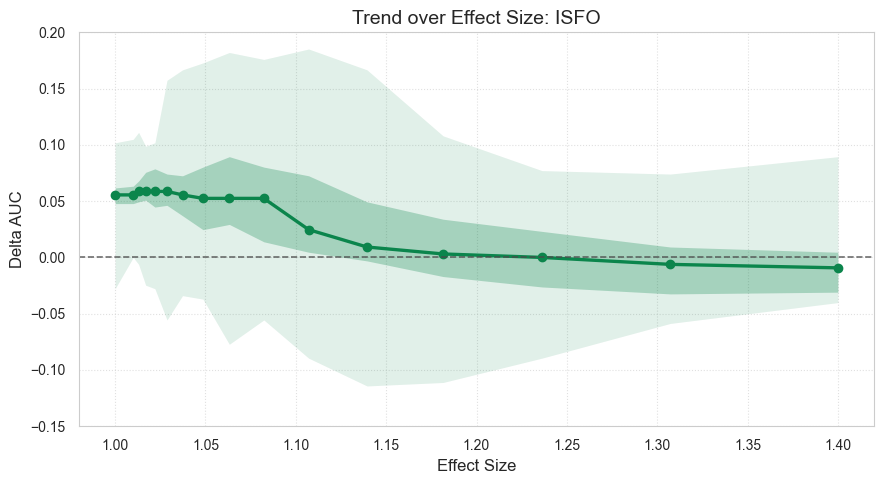

[INFO] Matplotlib figure saved successfully: c:\Users\adria\OneDrive\Escritorio\bueno_ibecp4048\docs\figures\sec4_1_2_effect_size_bounds_INSOC.png


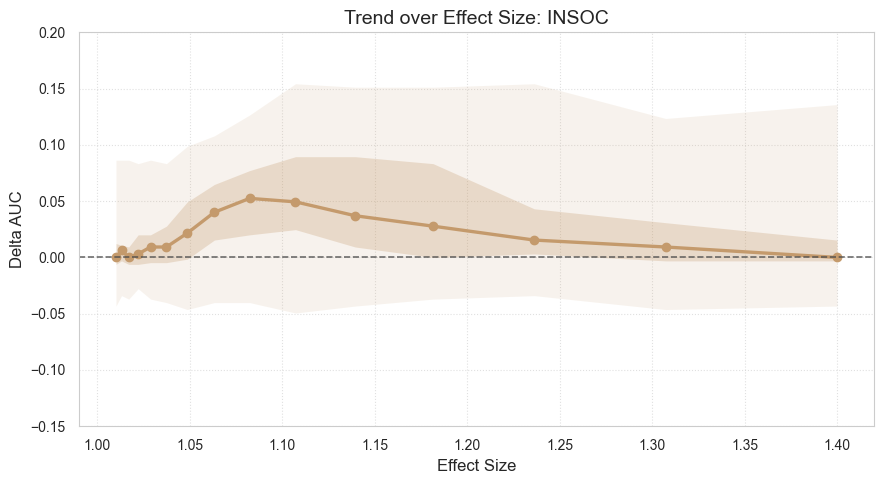

[INFO] Matplotlib figure saved successfully: c:\Users\adria\OneDrive\Escritorio\bueno_ibecp4048\docs\figures\sec4_1_2_effect_size_bounds_LOESSCorrector.png


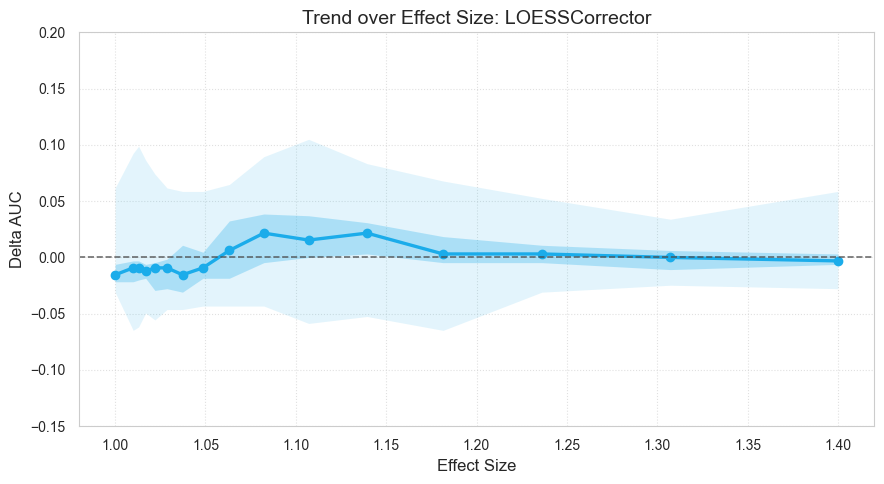

[INFO] Matplotlib figure saved successfully: c:\Users\adria\OneDrive\Escritorio\bueno_ibecp4048\docs\figures\sec4_1_2_effect_size_bounds_SERRFCorrector.png


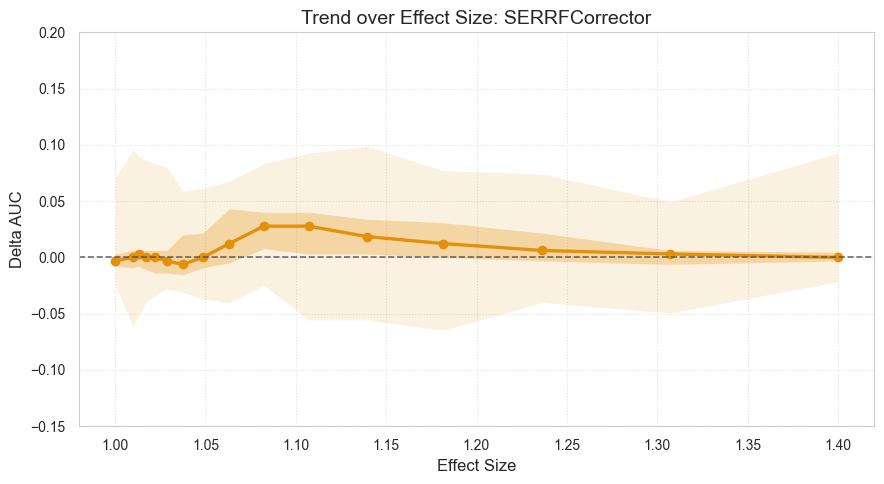

[INFO] Matplotlib figure saved successfully: c:\Users\adria\OneDrive\Escritorio\bueno_ibecp4048\docs\figures\sec4_1_2_absolute_auc_median_lines.png


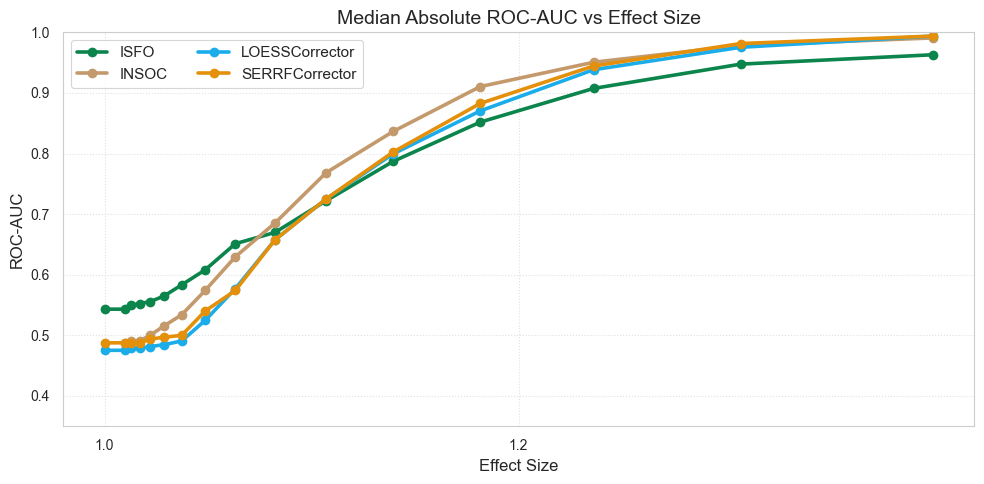

In [11]:
# ========================================
# EXECUTION 
# ========================================

df_master = load_paired_grid_results("./grid_results", selected_files=[
    "results_ISFO_b3_a1.csv",
    "results_INSOC_b3_a1.csv",
    "results_LOESSCorrector_frac0.35_it4.csv",
    "results_SERRFCorrector_est20_d2_s3.csv",
] )

# Keep downstream plots focused on requested methods
core_methods = [
    "Raw (No Correction)",
    "ISFO",
    "INSOC",
    "LOESSCorrector",
    "SERRFCorrector",
]
df_master_core = df_master[df_master['Method'].isin(core_methods)].copy()

# Filter out features with excessive inherent noise (RSD > 100%)
df_clean_core = filter_high_noise_features(df_master_core, threshold=100)
df_clean = df_clean_core.copy()  # Keep compatibility with downstream collinearity block

# Delta-AUC trends (linear effect-size axis, includes 1.0, with band widths)
plot_separated_effect_size_bounds(df_master_core, delta=True, methods_to_plot=core_methods)
#plot_feature_wise_delta_auc_scatter(df_master_core, target_effect_size=0, delta=True, methods_to_plot=core_methods)
#plot_effect_size_robustness_scatter(df_master_core, delta=True, methods_to_plot=core_methods)

# Unified absolute AUC median lines: 4 correction methods + raw
plot_absolute_auc_median_lines(df_master_core, methods=core_methods)




#### 4.1.3 Grid Results Statistical Analysis

##### Statistical analysis code

In [42]:
# ======================================================================================
# DATA PREPARATION HELPER
# ======================================================================================

def _prepare_paired_data(df, primary_method="ISFO"):
    """
    Pivots the master dataframe to create a paired structure, injects the 'Raw Baseline', 
    and critically maps the instrumental noise (RSD_QC_Raw) to each feature for sorting.
    """
    df_pivot = df.pivot_table(index=['Target_Feature', 'Effect_Size'], 
                              columns='Method', values='Delta_AUC').dropna()
    
    # Inject Raw Baseline for direct combinatorial testing and plotting
    df_pivot['Raw Baseline'] = 0.0
    
    # Map the instrumental noise (RSD_QC_Raw) to allow sorting by difficulty
    rsd_map = df[df['Method'] == primary_method].groupby('Target_Feature')['RSD_QC_Raw'].first()
    df_pivot = df_pivot.reset_index()
    df_pivot['RSD_QC_Raw'] = df_pivot['Target_Feature'].map(rsd_map)
    
    return df_pivot, rsd_map

# ======================================================================================
# BLOCK 1: GLOBAL STATISTICAL EVALUATION
# ======================================================================================

def run_global_hypothesis_tests(df, primary_method="ISFO", alpha=0.05):
    """
    Executes one-sided paired Wilcoxon signed-rank tests across the entire dataset.
    """
    print("=" * 80)
    print(f"GLOBAL STATISTICAL SUPREMACY ANALYSIS: {primary_method.upper()}")
    print("=" * 80)
    
    df_pivot, _ = _prepare_paired_data(df, primary_method)
    competitors = [m for m in df_pivot.columns if m not in [primary_method, 'Target_Feature', 'Effect_Size', 'RSD_QC_Raw']]
    
    results = []
    for comp in competitors:
        diff = df_pivot[primary_method] - df_pivot[comp]
        if np.all(diff == 0):
            stat, p_val = 0.0, 1.0
        else:
            stat, p_val = stats.wilcoxon(df_pivot[primary_method], df_pivot[comp], alternative='greater')
            
        median_adv = diff.median()
        q25, q75 = diff.quantile(0.25), diff.quantile(0.75)
        
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        conclusion = "Reject H0" if p_val < alpha else "Fail to Reject H0"
        
        results.append({
            'Competitor': comp,
            'Median_Advantage': median_adv,
            'Q25': q25, 'Q75': q75,
            'W_Statistic': stat,
            'P_Value': p_val,
            'Significance': sig,
            'Conclusion': conclusion
        })

    results_df = pd.DataFrame(results)
    for _, row in results_df.iterrows():
        print(f"Comparison: {primary_method} vs {row['Competitor']:<20}")
        print(f"  - Median Advantage : {row['Median_Advantage']:.4f} (IQR: [{row['Q25']:.4f}, {row['Q75']:.4f}])")
        print(f"  - W-Statistic      : {row['W_Statistic']:.1f}")
        print(f"  - Exact p-value    : {row['P_Value']:.4e} ({row['Significance']})")
        print(f"  - Conclusion       : {row['Conclusion']}\n")
        
    return results_df, df_pivot

# ======================================================================================
# BLOCK 2: MARGINAL EXTREMES AND GRANULAR ANALYSIS
# ======================================================================================

def analyze_marginal_extremes(df, primary_method="ISFO", alpha=0.05):
    """
    Computes the maximum and minimum median differences in performance 
    fixing specific features or effect sizes, and evaluates the statistical 
    significance (p-value) of that specific isolated subset.
    
    Additionally, it computes the exact percentage of the combinatorial space 
    (Effect Sizes or Target Features) where the primary method maintains a 
    statistically significant advantage (p < alpha).
    """
    print("=" * 100)
    print("MARGINAL EXTREMES ANALYSIS (FIXED DIMENSIONS)")
    print("=" * 100)
    
    df_pivot, rsd_map = _prepare_paired_data(df, primary_method)
    competitors = [m for m in df_pivot.columns if m not in ['Target_Feature', 'Effect_Size', 'RSD_QC_Raw', primary_method]]
    
    def _get_local_pvalue(subset, comp):
        """Helper to compute p-value for a specific isolated subset."""
        diff = subset[primary_method] - subset[comp]
        if len(subset) < 5 or np.all(diff == 0):
            return 1.0
        _, p = stats.wilcoxon(subset[primary_method], subset[comp], alternative='greater')
        return p

    for comp in competitors:
        print(f"\n--- {primary_method} vs {comp} ---")
        df_pivot[f'Adv_{comp}'] = df_pivot[primary_method] - df_pivot[comp]
        
        # =========================================================
        # 1. EFFECT SIZE DIMENSION
        # =========================================================
        agg_es = df_pivot.groupby('Effect_Size')[f'Adv_{comp}'].agg(['max', 'min', 'median'])
        best_es, worst_es = agg_es['median'].idxmax(), agg_es['median'].idxmin()
        
        p_best_es = _get_local_pvalue(df_pivot[df_pivot['Effect_Size'] == best_es], comp)
        p_worst_es = _get_local_pvalue(df_pivot[df_pivot['Effect_Size'] == worst_es], comp)
        
        sig_best = "***" if p_best_es < 0.001 else "**" if p_best_es < 0.01 else "*" if p_best_es < 0.05 else "ns"
        sig_worst = "***" if p_worst_es < 0.001 else "**" if p_worst_es < 0.01 else "*" if p_worst_es < 0.05 else "ns"
        
        # Calculate Global Robustness for Effect Sizes
        unique_es = df_pivot['Effect_Size'].unique()
        sig_es_count = sum(1 for es in unique_es if _get_local_pvalue(df_pivot[df_pivot['Effect_Size'] == es], comp) < alpha)
        pct_sig_es = (sig_es_count / len(unique_es)) * 100
        
        print(f"  [Effect Size Dimension]")
        print(f"    Highest Advantage : x{1+best_es:.3f} (+{agg_es.loc[best_es, 'median']:.4f}) | p-value: {p_best_es:.2e} ({sig_best})")
        print(f"    Lowest Advantage  : x{1+worst_es:.3f} ({agg_es.loc[worst_es, 'median']:.4f}) | p-value: {p_worst_es:.2e} ({sig_worst})")
        print(f"    Global Robustness : {primary_method} is statistically superior in {pct_sig_es:.1f}% of tested Effect Sizes ({sig_es_count}/{len(unique_es)}).")
        print()

        # =========================================================
        # 2. TARGET FEATURE DIMENSION
        # =========================================================
        agg_feat = df_pivot.groupby('Target_Feature')[f'Adv_{comp}'].agg(['max', 'min', 'median'])
        best_feat, worst_feat = agg_feat['median'].idxmax(), agg_feat['median'].idxmin()
        
        p_best_feat = _get_local_pvalue(df_pivot[df_pivot['Target_Feature'] == best_feat], comp)
        p_worst_feat = _get_local_pvalue(df_pivot[df_pivot['Target_Feature'] == worst_feat], comp)
        
        sig_bf = "***" if p_best_feat < 0.001 else "**" if p_best_feat < 0.01 else "*" if p_best_feat < 0.05 else "ns"
        sig_wf = "***" if p_worst_feat < 0.001 else "**" if p_worst_feat < 0.01 else "*" if p_worst_feat < 0.05 else "ns"

        # Calculate Global Robustness for Target Features
        unique_feats = df_pivot['Target_Feature'].unique()
        sig_feat_count = sum(1 for f in unique_feats if _get_local_pvalue(df_pivot[df_pivot['Target_Feature'] == f], comp) < alpha)
        pct_sig_feat = (sig_feat_count / len(unique_feats)) * 100

        print(f"  [Target Feature Dimension]")
        print(f"    Highest Advantage : F{int(best_feat):02d} (RSD: {rsd_map[best_feat]:.1f}%) -> +{agg_feat.loc[best_feat, 'median']:.4f} | p-value: {p_best_feat:.2e} ({sig_bf})")
        print(f"    Lowest Advantage  : F{int(worst_feat):02d} (RSD: {rsd_map[worst_feat]:.1f}%) -> {agg_feat.loc[worst_feat, 'median']:.4f} | p-value: {p_worst_feat:.2e} ({sig_wf})")
        print(f"    Global Robustness : {primary_method} is statistically superior in {pct_sig_feat:.1f}% of Target Features ({sig_feat_count}/{len(unique_feats)}).")




def run_stratified_hypothesis_tests(df, group_col='Effect_Size', primary_method="ISFO", alpha=0.05):
    """
    Iteratively executes paired tests over specific subsets. 
    Includes RSD_QC_Raw mapping to enable noise-sorted visualizations.
    """
    df_pivot, _ = _prepare_paired_data(df, primary_method)
    competitors = [m for m in df_pivot.columns if m not in ['Target_Feature', 'Effect_Size', 'RSD_QC_Raw', primary_method]]
    
    unique_groups = sorted(df_pivot[group_col].unique())
    stratified_results = []
    
    for group_val in unique_groups:
        subset = df_pivot[df_pivot[group_col] == group_val]
        if len(subset) < 5: continue
            
        for comp in competitors:
            diff = subset[primary_method] - subset[comp]
            if np.all(diff == 0):
                stat, p_val = 0.0, 1.0
            else:
                stat, p_val = stats.wilcoxon(subset[primary_method], subset[comp], alternative='greater')
                
            result_dict = {
                group_col: group_val,
                'Competitor': comp,
                'N_Samples': len(subset),
                'Median_Advantage': diff.median(),
                'P_Value': p_val,
                'Significant': p_val < alpha
            }
            # Carry over RSD for feature-based stratification
            if group_col == 'Target_Feature':
                result_dict['RSD_QC_Raw'] = subset['RSD_QC_Raw'].iloc[0]
                
            stratified_results.append(result_dict)
            
    # RESTORED: Explicit column definition to prevent Pandas broadcasting bugs
    columns = [group_col, 'Competitor', 'N_Samples', 'Median_Advantage', 'P_Value', 'Significant']
    if group_col == 'Target_Feature':
        columns.append('RSD_QC_Raw')
    return pd.DataFrame(stratified_results, columns=columns)


def plot_paired_advantage_distribution(df_pivot, primary_method="ISFO"):
    """
    Visualizes the empirical distribution of paired advantages across all evaluations.
    """
    competitors = [m for m in df_pivot.columns if m not in [primary_method, 'Target_Feature', 'Effect_Size', 'RSD_QC_Raw']]
    
    plot_data = []
    for comp in competitors:
        advantage = df_pivot[primary_method] - df_pivot[comp]
        temp_df = pd.DataFrame({'Advantage': advantage, 'Comparison': f"{primary_method} vs\n{comp}"})
        plot_data.append(temp_df)
        
    df_plot = pd.concat(plot_data)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    
    sns.boxplot(data=df_plot, x='Comparison', y='Advantage', color="lightgray", width=0.5, ax=ax, fliersize=4)
    ax.axhline(0, color='darkred', linestyle='--', linewidth=1.5, label=f"Null Hypothesis (Tie)")
    
    ax.set_title("Distribution of Paired Performance Advantage", fontweight='bold', fontsize=14)
    ax.set_ylabel(rf"$\Delta$ AUC ({primary_method}) - $\Delta$ AUC (Other)", fontweight='bold')
    ax.legend(loc='upper right', frameon=True)
    
    plt.tight_layout()
    save_clean_figure(fig, "sec4_1_3_paired_advantage_distribution.png")
    plt.show()


def plot_pvalue_evolution(stratified_df, group_col='Effect_Size', alpha=0.05):
    """
    Plots the -log10(p-value). If stratified by Feature, it rigorously sorts the X-axis 
    by Instrumental Noise (RSD) to expose resilience boundaries.
    """
    df_plot = stratified_df.copy()
    
    # RESTORED: Direct column access instead of the messy guessing logic
    df_plot['-log10(p)'] = -np.log10(df_plot['P_Value'] + 1e-300)
    threshold = -np.log10(alpha)
    
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.set_theme(style="whitegrid")
    
    # Handle Feature vs Effect Size sorting logic
    if group_col == 'Target_Feature':
        df_plot = df_plot.sort_values(by='RSD_QC_Raw')
        
        # BULLETPROOF FIX: Use list comprehension instead of .apply(axis=1)
        f_vals = np.asarray(df_plot['Target_Feature'])
        r_vals = np.asarray(df_plot['RSD_QC_Raw'])
        df_plot['X_Label'] = [f"F{int(f)}\n({r:.1f}%)" for f, r in zip(f_vals, r_vals)]
        
        x_target = 'X_Label'
        x_axis_title = "Target Feature (Sorted Low $\\rightarrow$ High RSD)"
    else:
        df_plot = df_plot.sort_values(by=group_col)
        x_target = group_col
        x_axis_title = "Effect Size"
    
    sns.lineplot(data=df_plot, x=x_target, y='-log10(p)', hue='Competitor', 
                 marker='o', linewidth=2.5, markersize=8, sort=False, ax=ax)
    
    ax.axhline(threshold, color='darkred', linestyle='--', linewidth=1.5, label=rf'$\alpha = {alpha}$ Threshold')
    
    if group_col == 'Effect_Size':
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{1+x:.3f}"))
    else:
        # Prevent Matplotlib warnings by setting ticks explicitly
        ax.set_xticks(range(len(df_plot[x_target].unique())))
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
        
    ax.set_xlabel(x_axis_title, fontweight='bold')
    ax.set_ylabel(r"$-\log_{10}(\text{p-value})$", fontweight='bold')
    ax.set_title("Evolution of Statistical Significance", fontweight='bold', fontsize=14)
    ax.legend(title="Methods", loc='upper left', bbox_to_anchor=(1.01, 1))
    
    plt.tight_layout()
    suffix = "feature" if group_col == 'Target_Feature' else "effect_size"
    save_clean_figure(fig, f"sec4_1_3_pvalue_evolution_{suffix}.png")
    plt.show()

##### Execution for the statistical analysis

GLOBAL STATISTICAL SUPREMACY ANALYSIS: ISFO
Comparison: ISFO vs INSOC               
  - Median Advantage : 0.0185 (IQR: [-0.0185, 0.0556])
  - W-Statistic      : 68931.5
  - Exact p-value    : 3.1835e-10 (***)
  - Conclusion       : Reject H0

Comparison: ISFO vs LOESSCorrector      
  - Median Advantage : 0.0432 (IQR: [-0.0031, 0.0772])
  - W-Statistic      : 87613.0
  - Exact p-value    : 8.5176e-35 (***)
  - Conclusion       : Reject H0

Comparison: ISFO vs SERRFCorrector      
  - Median Advantage : 0.0309 (IQR: [-0.0093, 0.0648])
  - W-Statistic      : 82441.5
  - Exact p-value    : 7.7594e-27 (***)
  - Conclusion       : Reject H0

Comparison: ISFO vs Raw Baseline        
  - Median Advantage : 0.0463 (IQR: [0.0000, 0.0679])
  - W-Statistic      : 88330.5
  - Exact p-value    : 8.5780e-42 (***)
  - Conclusion       : Reject H0

MARGINAL EXTREMES ANALYSIS (FIXED DIMENSIONS)

--- ISFO vs INSOC ---
  [Effect Size Dimension]
    Highest Advantage : x1.017 (+0.0586) | p-value: 2.33e-

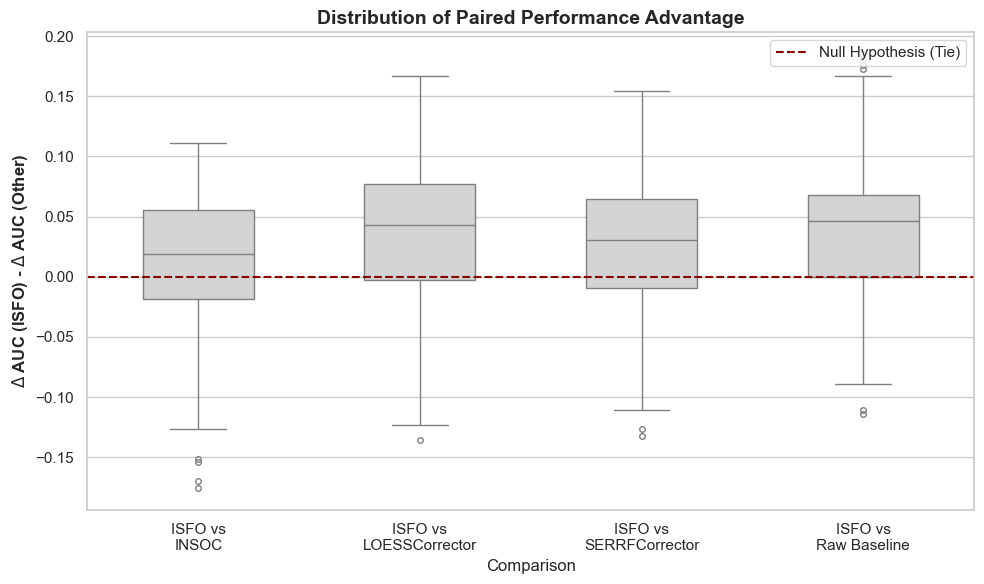

[INFO] Matplotlib figure saved successfully: c:\Users\adria\OneDrive\Escritorio\bueno_ibecp4048\docs\figures\sec4_1_3_pvalue_evolution_effect_size.png


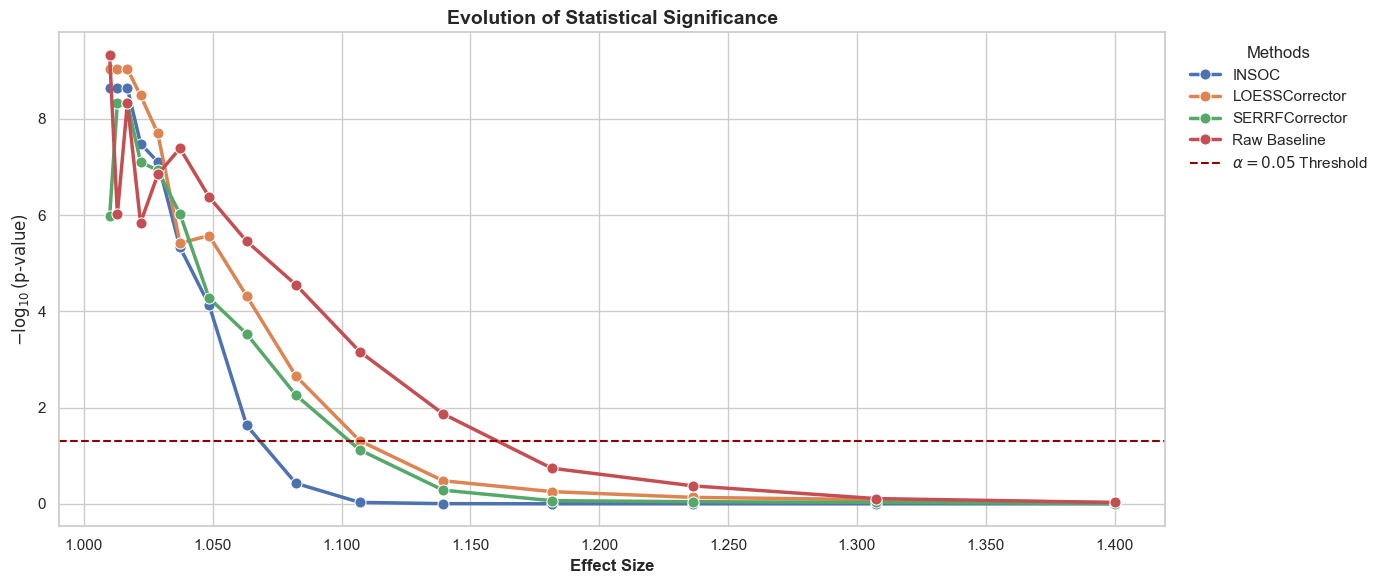

In [43]:

# ======================================================================================
# EXECUTION WORKFLOW
# ======================================================================================

# Global Tests
global_stats_df, paired_data_df = run_global_hypothesis_tests(df_master, primary_method="ISFO", alpha=0.05)

# Marginal Extremes (Now includes RSD context)
analyze_marginal_extremes(df_master, primary_method="ISFO")

# Paired advantage Distribution
plot_paired_advantage_distribution(paired_data_df, primary_method="ISFO")

# Effect Size Stratification
stratified_stats_es = run_stratified_hypothesis_tests(df_master, group_col='Effect_Size', primary_method="ISFO")
plot_pvalue_evolution(stratified_stats_es, group_col='Effect_Size')
